# Reconstruct Stokes profile from ERA5 wave output
- Author: Muxin Hu
- created time: 12.04.2026
- modified time: 13.04.2026

In [2]:
import xarray as xr
import numpy as np
import pyicon as pyic
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
import cmocean as cmo
import cartopy.crs as ccrs
import cartopy.feature as cfeature
%matplotlib inline
from distributed import Client, LocalCluster
import dask

----Start loading pyicon.
Loading default parameters from /home/m/m301254/Download/pyicon/pyicon/params_default.json.


ERROR 1: PROJ: proj_create_from_database: Open of /home/m/m301254/.conda/envs/env02_waves/share/proj failed


----Start loading pyicon.
----Pyicon was loaded successfully.
----Pyicon was loaded successfully.


In [3]:
cluster = LocalCluster(
    n_workers=24, 
    threads_per_worker=2,
    local_directory="/scratch/m/m301254/dask_tmp/"
)
client = Client(cluster)
client.restart()   
client

2026-05-22 10:24:34,942 - distributed.nanny - WARNING - Restarting worker
2026-05-22 10:24:34,958 - distributed.nanny - WARNING - Restarting worker
2026-05-22 10:24:34,969 - distributed.nanny - WARNING - Restarting worker
2026-05-22 10:24:34,983 - distributed.nanny - WARNING - Restarting worker
2026-05-22 10:24:34,997 - distributed.nanny - WARNING - Restarting worker
2026-05-22 10:24:35,014 - distributed.nanny - WARNING - Restarting worker
2026-05-22 10:24:35,016 - distributed.nanny - WARNING - Restarting worker
2026-05-22 10:24:35,022 - distributed.nanny - WARNING - Restarting worker
2026-05-22 10:24:35,027 - distributed.nanny - WARNING - Restarting worker
2026-05-22 10:24:35,034 - distributed.nanny - WARNING - Restarting worker
2026-05-22 10:24:35,046 - distributed.nanny - WARNING - Restarting worker
2026-05-22 10:24:35,048 - distributed.nanny - WARNING - Restarting worker
2026-05-22 10:24:35,216 - distributed.nanny - WARNING - Restarting worker
2026-05-22 10:24:35,219 - distributed.

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 24
Total threads: 48,Total memory: 251.62 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33625,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:37693,Total threads: 2
Dashboard: http://127.0.0.1:37165/status,Memory: 10.48 GiB
Nanny: tcp://127.0.0.1:39115,


2026-05-22 10:53:24,695 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 0c6615bd9754dd70945322d44656935f initialized by task ('rechunk-merge-rechunk-transfer-3fe74f97faf967ba7e42727482c6204f', 0, 0, 0, 0, 0, 2, 2, 0) executed on worker tcp://127.0.0.1:42157
2026-05-22 10:53:24,755 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 58a18af3c6f93f6f27f91421448aa19a initialized by task ('rechunk-merge-rechunk-transfer-5897adc1c57b1f341f17a136c92be082', 0, 0, 0, 0, 0, 2, 2, 0) executed on worker tcp://127.0.0.1:43469
2026-05-22 10:54:04,165 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 58a18af3c6f93f6f27f91421448aa19a deactivated due to stimulus 'task-finished-1779440044.1643727'
2026-05-22 10:54:04,539 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 0c6615bd9754dd70945322d44656935f deactivated due to stimulus 'task-finished-1779440044.5379555'
2026-05-22 10:57:06,200 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 61ceba3db2c0f541

## Read Data

In [3]:
# read data
wave_globe = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/processed_data/era5/hourly/era5_Stokes_mean_wave_parameters.grib",engine="cfgrib")
stokes_globe = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/processed_data/era5/hourly/era5_Stokes_surface_uv_2024.grib",engine="cfgrib")

In [16]:
wave_globe

<xarray.Dataset> Size: 82GB
Dimensions:     (time: 8784, latitude: 361, longitude: 720)
Coordinates:
  * time        (time) datetime64[ns] 70kB 2024-01-01 ... 2024-12-31T23:00:00
  * latitude    (latitude) float64 3kB 90.0 89.5 89.0 88.5 ... -89.0 -89.5 -90.0
  * longitude   (longitude) float64 6kB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
    number      int64 8B ...
    step        timedelta64[ns] 8B ...
    meanSea     float64 8B ...
    valid_time  (time) datetime64[ns] 70kB dask.array<chunksize=(8784,), meta=np.ndarray>
Data variables:
    mwd         (time, latitude, longitude) float32 9GB dask.array<chunksize=(2164, 88, 176), meta=np.ndarray>
    swh         (time, latitude, longitude) float32 9GB dask.array<chunksize=(2164, 88, 176), meta=np.ndarray>
    mdts        (time, latitude, longitude) float32 9GB dask.array<chunksize=(2164, 88, 176), meta=np.ndarray>
    mdww        (time, latitude, longitude) float32 9GB dask.array<chunksize=(2164, 88, 176), meta=np.ndarray>
    mp1         (time, latitude, longitude) float32 9GB dask.array<chunksize=(2164, 88, 176), meta=np.ndarray>
    p1ps        (time, latitude, longitude) float32 9GB dask.array<chunksize=(2164, 88, 176), meta=np.ndarray>
    p1ww        (time, latitude, longitude) float32 9GB dask.array<chunksize=(2164, 88, 176), meta=np.ndarray>
    shts        (time, latitude, longitude) float32 9GB dask.array<chunksize=(2164, 88, 176), meta=np.ndarray>
    shww        (time, latitude, longitude) float32 9GB dask.array<chunksize=(2164, 88, 176), meta=np.ndarray>
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-05T11:14 GRIB to CDM+CF via cfgrib-0.9.1...

In [17]:
stokes_globe

<xarray.Dataset> Size: 18GB
Dimensions:     (time: 8784, latitude: 361, longitude: 720)
Coordinates:
  * time        (time) datetime64[ns] 70kB 2024-01-01 ... 2024-12-31T23:00:00
  * latitude    (latitude) float64 3kB 90.0 89.5 89.0 88.5 ... -89.0 -89.5 -90.0
  * longitude   (longitude) float64 6kB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
    number      int64 8B ...
    step        timedelta64[ns] 8B ...
    meanSea     float64 8B ...
    valid_time  (time) datetime64[ns] 70kB dask.array<chunksize=(8784,), meta=np.ndarray>
Data variables:
    ust         (time, latitude, longitude) float32 9GB dask.array<chunksize=(2164, 88, 176), meta=np.ndarray>
    vst         (time, latitude, longitude) float32 9GB dask.array<chunksize=(2164, 88, 176), meta=np.ndarray>
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-05T11:14 GRIB to CDM+CF via cfgrib-0.9.1...

## Estimate: Stokes transport
- Formula: $$\mathbf{V_s}\approx \frac{\pi H_s^2}{8 \overline{T}} \hat{\mathbf {k}}_s$$
    - using: mean wave significant height $H_s$, direction $\hat{\mathbf {k}}_s$, and period $\overline{T}$, either from:
        - **Separated in wind wave and total swells**
            - Treating each kind as monochromatic wave with narrow spectrum band
            - Two wave systems exist, can account for opposing Stokes transports from two groups. More consistent
        - **Combined wind waves and swell**
            - single-direction approximation
    - the mean wave period should be the **mean wave period based on first moment of waves** by definition
    - mean wave direction is a better directional proxy for transport than surface Stokes drift (Breivik et al., 2014)
        - "**Breivil et al. (2014) suggests that it is better to estimate the transport direction from the mean wave direction raher than from the surface Stokes advection**, as the Stokes transport is more influenced by the low-frequency wave (i.e., swells) in principle. The mean wave direction represents bulk spectrum, and is much closer to transport direction. Evidence shows mean wave direction differing from transport direction only by ~2 degree on average"

In [4]:
print(wave_globe["shww"].chunks)
print(wave_globe["shts"].chunks)

((720, 720, 720, 720, 720, 720, 720, 720, 720, 720, 720, 720, 144), (180, 180, 1), (360, 360))
((720, 720, 720, 720, 720, 720, 720, 720, 720, 720, 720, 720, 144), (180, 180, 1), (360, 360))


In [7]:
# Estimate the Stokes transport (unit: m^2/s)
def estimate_stokes_transport(Hs, T, theta_from_deg):
    """
    theta_drom_deg: the raw ERA5 data are degrees that waves are coming FROM, 
    so zero means 'coming from the north' and 90 'coming from the east'.
    """
    # convert coming from to propagating toward
    theta = np.deg2rad((theta_from_deg + 180) % 360)

    Vs_mag = np.pi * Hs**2 / (8 * T)
    Vs_u = Vs_mag * np.sin(theta) # eastward
    Vs_v = Vs_mag * np.cos(theta) # northward
    
    return Vs_u, Vs_v

# No separation between wind wave and total swells
- Use the direct estimation of Stokes transport $\mathbf V_{s}$ from the mean wave direction/period/height
- Stokes profile direction follows the surface Stokes velocity direction
- Two approximated profiles:
    - Exponential Integral Profile (Breivik et al. 2014)
    - Phillips Spectrum Profile (Breivik et al. 2016)

## Stokes transport from mean wave parameters

In [6]:
# directly estimated from mean wave direction/period/height
Vst_u_direct, Vst_v_direct = estimate_stokes_transport(wave_globe["swh"], wave_globe["mp1"], wave_globe["mwd"])
ds_Vst_direct = xr.Dataset({
    "Vst_u_direct":  Vst_u_direct,
    "Vst_v_direct":  Vst_v_direct
}).compute()

/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 10.35 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [ ]:
ds_Vst_direct.to_netcdf("/work/mh0033/m301254/proj_surfwave/processed_data/era5/hourly/era5_Stokes_transport_estimated_direct_2024.nc")

## Exponential Integral Profile (Breivik et al. 2014)
- Following the parameterization of **Breivik et al. (2014)** to approximate the Stokes drift profile into an exponential integral profile base on two estimated parameters: 
    - the Stokes transport ($\mathbf V_s$) 
    - the surface Stokes drift velocity ($\mathbf u_s(0)$). 
- **The Stokes drift velocity as a function of depth $z$ (positive downward)** is given by: $$\mathbf {u}_s(z)=\mathbf {u}_s(0)\frac{e^{-2k_ez}}{1+Ck_ez} \tag{1}$$
    - where: $$C\approx 8 \tag{2}$$
    - and the **inverse depth scale $k_e$** is defined as $$ k_e =\frac{|\mathbf {u}_s(0)|[e^{1/4}E_1(1/4)]}{8|\mathbf V_s|},\quad \text{with}\quad e^{1/4}E_1(1/4)\approx 1.34. \tag{3}$$
        - According to Janssen et al., (2013) "Air-Sea Interaction and Surface Waves", the inverse depth scale is calculated using the magnitudes of both the surface Stokes drift velocity and the estimated Stokes transport.

In [30]:
ds_Vst_direct = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/processed_data/era5/hourly/era5_Stokes_transport_estimated_direct_2024.nc")

### 2024 January

In [31]:
# surface Stokes
chunks = {"time": 48, "latitude": 88, "longitude": 176}

ust0 = stokes_globe["ust"].sel(time=slice("2024-01-01", "2024-02-01")).chunk(chunks)
vst0 = stokes_globe["vst"].sel(time=slice("2024-01-01", "2024-02-01")).chunk(chunks)
ust0_mag = xr.apply_ufunc(
    np.hypot, ust0, vst0,
    dask="parallelized",
    output_dtypes=[float]
)

Vst_u_direct = ds_Vst_direct["Vst_u_direct"].sel(time=slice("2024-01-01", "2024-02-01")).chunk(chunks)
Vst_v_direct = ds_Vst_direct["Vst_v_direct"].sel(time=slice("2024-01-01", "2024-02-01")).chunk(chunks)
Vst_mag = xr.apply_ufunc(
    np.hypot,
    Vst_u_direct,
    Vst_v_direct,
    dask="parallelized",
    output_dtypes=[float]
)

In [32]:
print(type(ust0_mag.data))
print(type(Vst_mag.data))

<class 'dask.array.core.Array'>
<class 'dask.array.core.Array'>


In [33]:
# inverse depth scale
k_e = (1.34 * ust0_mag) / (8 * xr.where(Vst_mag > 0, Vst_mag, np.nan))
k_e = k_e.chunk(ust0.chunksizes).persist()

In [34]:
# define the depth space
z = xr.DataArray(
    np.array([0, 1, 2, 3, 4, 5, 7, 9, 11, 13, 15, 20, 25, 30, 40, 50]),
    dims="depth",
    coords={"depth": np.array([0, 1, 2, 3, 4, 5, 7, 9, 11, 13, 15, 20, 25, 30, 40, 50])},
    name="depth",
    attrs={
        "long_name": "depth below sea surface",
        "units": "m",
        "positive": "down"
    }
)

# broadcast to 4D
k_e_4d, z_4d = xr.broadcast(k_e, z)
ust0_4d, _ = xr.broadcast(ust0, z)
vst0_4d, _ = xr.broadcast(vst0, z)

In [ ]:
# profile shape
f_z = np.exp(-2 * k_e_4d * z_4d) / (1 + 8 * k_e_4d * z_4d)

# two directions
ust_z = ust0_4d * f_z
vst_z = vst0_4d * f_z

In [ ]:
ds_profile = xr.Dataset({
    "ust_z": ust_z,
    "vst_z": vst_z,
    "k_e": k_e
})
ds_profile = ds_profile.astype("float32")

# final chunks for consistency and efficient compression
final_chunks = {
    "time": 48,
    "latitude": 88,
    "longitude": 176,
    "depth": -1
}

ds_profile = ds_profile.chunk(final_chunks)

# compression settings
encoding = {
    "ust_z": {"zlib": True, "complevel": 4, "shuffle": True, "chunksizes": (48, 88, 176, 16)},
    "vst_z": {"zlib": True, "complevel": 4, "shuffle": True, "chunksizes": (48, 88, 176, 16)},
    "k_e":   {"zlib": True, "complevel": 4, "shuffle": True, "chunksizes": (48, 88, 176)}
}

# output
outdir = "/work/mh0033/m301254/proj_surfwave/processed_data/era5/hourly/"
ds_profile.to_netcdf(
    f"{outdir}era5_Stokes_profile_exponential_2024_Jan.nc",
    encoding=encoding
)

In [4]:
outdir = "/work/mh0033/m301254/proj_surfwave/processed_data/era5/hourly/"
stokes_uv = xr.open_dataset(f"{outdir}era5_Stokes_profile_exponential_2024_Jan.nc")
stokes_uv_so = stokes_uv.isel(latitude=slice(-60, -50), longitude=slice(260, 270))

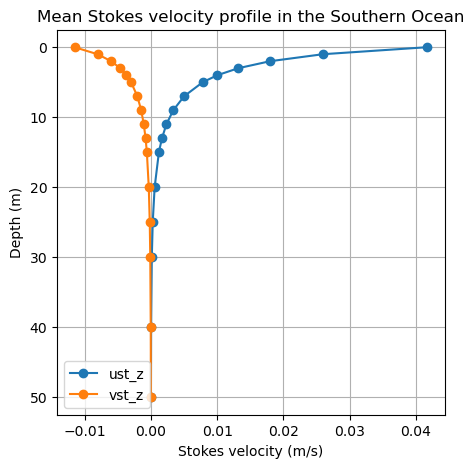

In [52]:
# calculate the mean profile in the Southern Ocean region
stokes_uv_so_mean = stokes_uv_so.mean(dim={"time", "latitude", "longitude"})

# plot the mean profile
plt.figure(figsize=(5, 5))
plt.plot(stokes_uv_so_mean["ust_z"], stokes_uv_so_mean["depth"], label="ust_z", marker="o")
plt.plot(stokes_uv_so_mean["vst_z"], stokes_uv_so_mean["depth"], label="vst_z", marker="o")
plt.gca().invert_yaxis()
plt.xlabel("Stokes velocity (m/s)")
plt.ylabel("Depth (m)")
plt.title("Mean Stokes velocity profile in the Southern Ocean")
plt.legend()
plt.grid()
plt.show()

## Phillips Spectrum Profile (Breivik et al. 2016)
- Following the **Breivik et al. 2016** to approximate Stokes drift profile as:  $$\begin{equation} \mathbf{v}_s(z)\approx v_0 \biggl\{e^{-2\overline{k}|z|} -\beta\sqrt{2\pi \overline{k}|z|}\biggr[\mathbf{erfc}(\sqrt{2\overline{k}|z|})\biggr]\biggl\} \end{equation}$$
- where:
    - $\beta$: a parameter, which is exactly one in Phillips spectrum
        - (Breivik et al., 2016)found $\beta=1$ yield good agreement between modeled and parameterised Stokes drift profiles.
    - $\overline k$: **inverse depth scale**, which can be determined given an estimate of the transport $\mathbf{V}_s$ and the surface Stokes drift velocity $v_0$ by: $$\overline k=\frac{v_0}{2\mathbf{V}_s}(1-2\beta/3) $$
- Estimation of Stokes transport according to Eq. (26) (equivalent to Eq. (38)) using bulk-wave parameters
- Surface stokes drift velocity can to be separated into wind wave and total swells (or swell partition 1/2/3) components

### 2024 January

In [4]:
import scipy.special as sps
ds_Vst_direct = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/processed_data/era5/hourly/era5_Stokes_transport_estimated_direct_2024.nc")

In [5]:
# surface Stokes
chunks = {"time": 48, "latitude": 88, "longitude": 176}

ust0 = stokes_globe["ust"].sel(time=slice("2024-01-01", "2024-02-01")).chunk(chunks)
vst0 = stokes_globe["vst"].sel(time=slice("2024-01-01", "2024-02-01")).chunk(chunks)
ust0_mag = xr.apply_ufunc(
    np.hypot, ust0, vst0,
    dask="parallelized",
    output_dtypes=[float]
)

Vst_u_direct = ds_Vst_direct["Vst_u_direct"].sel(time=slice("2024-01-01", "2024-02-01")).chunk(chunks)
Vst_v_direct = ds_Vst_direct["Vst_v_direct"].sel(time=slice("2024-01-01", "2024-02-01")).chunk(chunks)
Vst_mag = xr.apply_ufunc(
    np.hypot,
    Vst_u_direct,
    Vst_v_direct,
    dask="parallelized",
    output_dtypes=[float]
)

In [6]:
beta = 1.0
eps = 1e-12

Vst_safe = xr.where(Vst_mag > eps, Vst_mag, np.nan)

# k_bar
k_bar = (ust0_mag / (2 * Vst_safe)) * (1 - 2 * beta / 3)

k_bar = k_bar.chunk(chunks).persist()

In [7]:
# define the depth space
z = xr.DataArray(
    np.array([0, 1, 2, 3, 4, 5, 7, 9, 11, 13, 15, 20, 25, 30, 40, 50]),
    dims="depth",
    coords={"depth": np.array([0, 1, 2, 3, 4, 5, 7, 9, 11, 13, 15, 20, 25, 30, 40, 50])},
    name="depth",
    attrs={
        "long_name": "depth below sea surface",
        "units": "m",
        "positive": "down"
    }
)

In [9]:
# argument 
arg = 2 * k_bar * z
sqrt_arg = np.sqrt(arg)

# erfc term
erfc_term = sps.erfc(sqrt_arg)

# full shape function
f_z = np.exp(-arg) - beta * np.sqrt(np.pi * arg) * erfc_term

In [10]:
ust_z = ust0 * f_z
vst_z = vst0 * f_z

ds_profile_phillips = xr.Dataset({
    "ust_z": ust_z,
    "vst_z": vst_z,
    "k_bar": k_bar
})

# reduce precision
ds_profile_phillips = ds_profile_phillips.astype("float32")

# attach coordinate
ds_profile_phillips = ds_profile_phillips.assign_coords(depth=z)

# final chunks for consistency and efficient compression
final_chunks = {
    "time": 48,
    "latitude": 88,
    "longitude": 176,
    "depth": -1
}

ds_profile_phillips = ds_profile_phillips.chunk(final_chunks)

# compression settings
encoding = {
    "ust_z": {"zlib": True, "complevel": 4, "shuffle": True, "chunksizes": (48, 88, 176, 16)},
    "vst_z": {"zlib": True, "complevel": 4, "shuffle": True, "chunksizes": (48, 88, 176, 16)},
    "k_bar": {"zlib": True, "complevel": 4, "shuffle": True, "chunksizes": (48, 88, 176)}
}

outdir = "/work/mh0033/m301254/proj_surfwave/processed_data/era5/hourly/"
ds_profile_phillips.to_netcdf(
    f"{outdir}era5_Stokes_profile_phillips_2024_Jan.nc",
    encoding=encoding
)

### Redo

In [8]:
# read data
wave_globe = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/processed_data/era5/hourly/era5_Stokes_mean_wave_parameters.grib",engine="cfgrib")
stokes_globe = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/processed_data/era5/hourly/era5_Stokes_surface_uv_2024.grib",engine="cfgrib")
ds_Vst_direct = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/processed_data/era5/hourly/era5_Stokes_transport_estimated_direct_2024.nc")

chunks = {"time": 96, "latitude": 88, "longitude": 176}
time_sel = slice("2024-01-01", "2024-02-01")
EPS = 1e-12

# load stokes drift and wave direction
ust0 = stokes_globe["ust"].sel(time=time_sel).chunk(chunks)
vst0 = stokes_globe["vst"].sel(time=time_sel).chunk(chunks)
Vst_u_direct = ds_Vst_direct["Vst_u_direct"].sel(time=time_sel).chunk(chunks)
Vst_v_direct = ds_Vst_direct["Vst_v_direct"].sel(time=time_sel).chunk(chunks)

# Transport magnitude
Vst_mag = xr.apply_ufunc(
    np.hypot, Vst_u_direct, Vst_v_direct,
    dask="parallelized",
    output_dtypes=[float]
)

# Phillips profile function
import scipy.special as sps
def Phillips_profile(ust_surface, vst_surface, Vst_mag, beta=1.0):
    # surface velocity magnitude
    ust_mag = xr.apply_ufunc(
        np.hypot, ust_surface, vst_surface,
        dask="parallelized",
        output_dtypes=[float])
    # Stokes transport (considered as scalar)
    Vst_safe = xr.where(Vst_mag > EPS, Vst_mag, np.nan)
    # inverse depth scale
    k_bar = (ust_mag / (2 * Vst_safe)) * (1 - 2 * beta / 3)
    # z-cooridnate
    z = xr.DataArray(np.array([0, 1, 2, 3, 4, 5, 7, 9, 11, 13, 15, 20, 25, 30, 40, 50]),
                     dims="depth",
                     coords={
                         "depth": np.array([0, 1, 2, 3, 4, 5, 7, 9, 11, 13, 15, 20, 25, 30, 40, 50])
                         })
    # Phillips profile shape function
    arg = 2 * k_bar * z
    sqrt_arg = np.sqrt(arg)
    erfc_term = sps.erfc(sqrt_arg)
    f_z = (np.exp(-arg) - beta * np.sqrt(np.pi * arg) * erfc_term)
    # apply the shape function to two components
    ust_z = ust_surface * f_z
    vst_z = vst_surface * f_z
    ds = xr.Dataset({"ust_z": ust_z, "vst_z": vst_z, "k_bar": k_bar})
    ds = ds.assign_coords(depth=z)

    return ds

ds_profile_direct = Phillips_profile(ust0, vst0, Vst_mag)

# final chunks for consistency
final_chunks = {"time": 96, "latitude": 88, "longitude": 176, "depth": -1}
ds_profile_direct = ds_profile_direct.chunk(final_chunks)
ds_profile_direct = ds_profile_direct.astype("float32")

# Encoding settings for compression
encoding = {
    "ust_z": {"zlib": True, "complevel": 4, "shuffle": True, "chunksizes": (96, 88, 176, 16)},
    "vst_z": {"zlib": True, "complevel": 4, "shuffle": True, "chunksizes": (96, 88, 176, 16)},
    "k_bar": {"zlib": True, "complevel": 4, "shuffle": True, "chunksizes": (96, 88, 176)}
}

# save
outdir = "/work/mh0033/m301254/proj_surfwave/processed_data/era5/hourly/"
ds_profile_direct.to_netcdf(f"{outdir}era5_Stokes_profile_phillips_2024_Jan_Redo.nc", encoding=encoding)

## Compare profiles

In [2]:
outdir = "/work/mh0033/m301254/proj_surfwave/processed_data/era5/hourly/"
p_integral = xr.open_dataset(f"{outdir}era5_Stokes_profile_exponential_2024_Jan.nc")
p_phllips = xr.open_dataset(f"{outdir}era5_Stokes_profile_phillips_2024_Jan.nc")

# southern ocean region
p_integral_so = p_integral.sel(latitude=slice(-50, -55), longitude=slice(260, 265))
p_phillips_so = p_phllips.sel(latitude=slice(-50, -55), longitude=slice(260, 265))

# Tropical Pacific region
p_integral_tp = p_integral.sel(latitude=slice(0, -5), longitude=slice(260, 265))
p_phillips_tp = p_phllips.sel(latitude=slice(0, -5), longitude=slice(260, 265))

# time-averaged regional-mean profile
# p_integral_so_mean = p_integral_so.mean(dim={"time", "latitude", "longitude"})
# p_phillips_so_mean = p_phillips_so.mean(dim={"time", "latitude", "longitude"})

# p_integral_tp_mean = p_integral_tp.mean(dim={"time", "latitude", "longitude"})
# p_phillips_tp_mean = p_phillips_tp.mean(dim={"time", "latitude", "longitude"})

# regional-mean profile
p_integral_so_reg = p_integral_so.mean(dim={"latitude", "longitude"})
p_phillips_so_reg = p_phillips_so.mean(dim={"latitude", "longitude"})

p_integral_tp_reg = p_integral_tp.mean(dim={"latitude", "longitude"})
p_phillips_tp_reg = p_phillips_tp.mean(dim={"latitude", "longitude"})

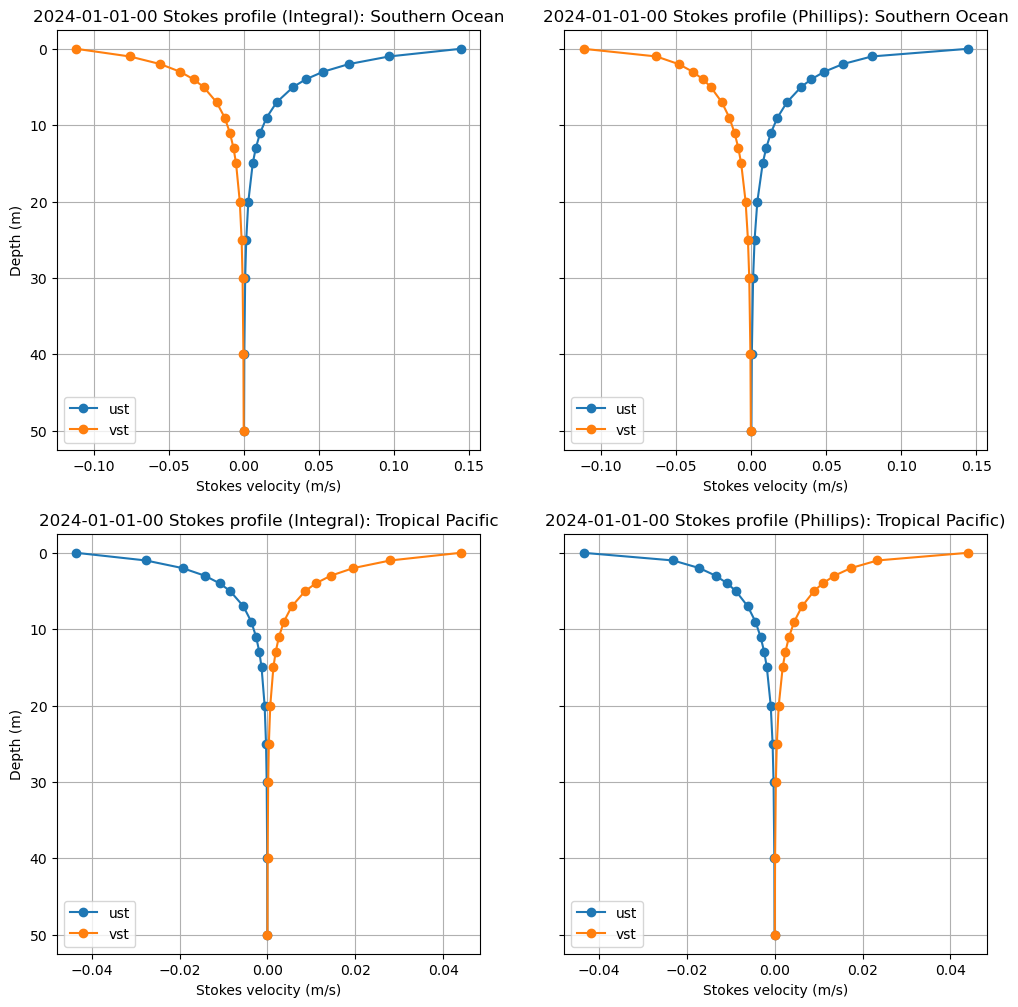

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 12), sharey=True)

# Integral profile
axes[0,0].plot(p_integral_so_reg["ust_z"].isel(time=500), p_integral_so_reg["depth"], label="ust", marker="o")
axes[0,0].plot(p_integral_so_reg["vst_z"].isel(time=500), p_integral_so_reg["depth"], label="vst", marker="o")
axes[0,0].invert_yaxis()
axes[0,0].set_xlabel("Stokes velocity (m/s)")
axes[0,0].set_ylabel("Depth (m)")
axes[0,0].set_title("2024-01-01-00 Stokes profile (Integral): Southern Ocean")
axes[0,0].legend()
axes[0,0].grid()

# Phillips profile
axes[0,1].plot(p_phillips_so_reg["ust_z"].isel(time=500), p_phillips_so_reg["depth"], label="ust", marker="o")
axes[0,1].plot(p_phillips_so_reg["vst_z"].isel(time=500), p_phillips_so_reg["depth"], label="vst", marker="o")
axes[0,1].set_xlabel("Stokes velocity (m/s)")
axes[0,1].set_title("2024-01-01-00 Stokes profile (Phillips): Southern Ocean")
axes[0,1].legend()
axes[0,1].grid()

# Integral profile
axes[1,0].plot(p_integral_tp_reg["ust_z"].isel(time=500), p_integral_tp_reg["depth"], label="ust", marker="o")
axes[1,0].plot(p_integral_tp_reg["vst_z"].isel(time=500), p_integral_tp_reg["depth"], label="vst", marker="o")
axes[1,0].set_xlabel("Stokes velocity (m/s)")
axes[1,0].set_ylabel("Depth (m)")
axes[1,0].set_title("2024-01-01-00 Stokes profile (Integral): Tropical Pacific")
axes[1,0].legend()
axes[1,0].grid()

# Phillips profile
axes[1,1].plot(p_phillips_tp_reg["ust_z"].isel(time=500), p_phillips_tp_reg["depth"], label="ust", marker="o")
axes[1,1].plot(p_phillips_tp_reg["vst_z"].isel(time=500), p_phillips_tp_reg["depth"], label="vst", marker="o")
axes[1,1].set_xlabel("Stokes velocity (m/s)")
axes[1,1].set_title("2024-01-01-00 Stokes profile (Phillips): Tropical Pacific)")
axes[1,1].legend()
axes[1,1].grid()

# plt.tight_layout()
plt.show()

# Separate surface Stokes drift velocity into (1) wind wave and (3) total swells component
**One can separate the surface Stokes drift velocity** $u_{so}$ to: $$u_{so}\hat{\theta}=u_{s,ww}\hat{\theta}_{ww}+u_{s,ts}\hat{\theta}_{ts}$$
- where:
    - $\hat{\theta}=(\sin{\theta}, \cos{\theta})$, $\hat{\theta}_{ww}=(\sin{\theta_{ww}}, \cos{\theta_{ww}})$ and $\hat{\theta}_{ts}=(\sin{\theta_{ts}}, \cos{\theta_{ts}})$: direction vectors for original surface Stokes drift velocity, wind waves and total swell components, respectively.
    - $u_{so}$, $u_{s,ww}$ and $u_{s,ts}$: velocity magnitude (scalar) for original surface Stokes drift velocity, wind waves and total swell components, respectively.

Given that: $$\hat{\theta}_{ts} \times \hat{\theta}_{ts} = 0$$
- one can get: $$\begin{align} u_{so}(\hat{\theta} \times \hat{\theta}_{ts})&=u_{s,ww}(\hat{\theta}_{ww}\times \hat{\theta}_{ts})\\ u_{so}(\hat{\theta} \times \hat{\theta}_{ww})&=u_{s,ts}(\hat{\theta}_{ts}\times \hat{\theta}_{ww})\end{align}$$
- cross products of unit velocity direction vector: $$\begin{align} \hat{\theta} \times \hat{\theta}_{ts} &= \sin{(\theta - \theta_{ts})} \\ \hat{\theta}_{ww} \times \hat{\theta}_{ts} &= \sin{(\theta_{ww} - \theta_{ts})} \\ \hat{\theta}_{ts} \times \hat{\theta}_{ww} &= \sin{(\theta_{ts} - \theta_{ww})}\end{align}$$
- Thus: $$\begin{align} u_{s,ww}&=u_{so}\frac{\sin{(\theta - \theta_{ts})}}{\sin{(\theta_{ww} - \theta_{ts})}} \\u_{s,ts}&=u_{so}\frac{\sin{(\theta - \theta_{ww})}}{\sin{(\theta_{ts} - \theta_{ww})}}  \end{align}$$

**The above expressions become ill-conditioned when the wind sea and swell directions are nearly aligned or opposite** $\sin(\theta_{ts} - \theta_{ww})\approx 0$. In this case, small numerical errors can lead ot large uncertainties or even negative values of the estimated magnitudes. To mitigate this, the practical procedure is:
- Compute both $u_{s,ww}, u_{s,ts}$ using the two projection formulas above
- Retain the component that yields a **nonnegative magnitude**, and compute the other component from the vector relation $u_{so}\hat{\theta}=u_{s,ww}\hat{\theta}_{ww}+u_{s,ts}\hat{\theta}_{ts}$.
This ensures a physically consistent decomposition where component magnitudes remain nonnegative.


## Check if decomposition yields infinitive magnitude

In [ ]:
chunks = {"time": 48, "latitude": 88, "longitude": 176}
# surface Stokes
ust0 = stokes_globe["ust"].sel(time=slice("2024-01-01", "2024-02-01")).chunk(chunks)
vst0 = stokes_globe["vst"].sel(time=slice("2024-01-01", "2024-02-01")).chunk(chunks)

# mean wave direction
mdww = wave_globe["mdww"].sel(time=slice("2024-01-01", "2024-02-01")).chunk(chunks)
mdts = wave_globe["mdts"].sel(time=slice("2024-01-01", "2024-02-01")).chunk(chunks)

# direction vector
theta = np.arctan2(ust0, vst0)  # --> u = U*sin(\theta), v = U*cos(\theta), degress rotate from north and going clockwise
theta_ww = np.deg2rad((mdww + 180) % 360)
theta_ts = np.deg2rad((mdts + 180) % 360)

In [5]:
# check when sin(theta_ww-theta_ts)~0, if  sin(theta-theta_ts) is also ~0
mask = np.abs(np.sin(theta_ww - theta_ts)) < 1e-3
test = np.abs(np.sin(theta - theta_ts))
print(test.where(mask).quantile([0.25, 0.5, 0.75, 0.95]).compute())

/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 12.74 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


<xarray.DataArray (quantile: 4)> Size: 32B
array([0.02399962, 0.05772301, 0.13643429, 0.6216466 ])
Coordinates:
  * quantile  (quantile) float64 32B 0.25 0.5 0.75 0.95


- the above quantile shows the $|\sin{\theta - \theta_{ts}}|$ conditioned on $|\sin{\theta_{ww} - \theta_{ts}}|\lt 10^{-3}$ (i.e., wind wave direction aligns or opposite to the swell direction).
- interpretation:
    - mean (0.058): mean $\Delta \theta = \Delta (\theta - \theta_{ts})\approx 3.3$
    - 95th percentile (0.62): large misalignment
    - when wind seea and swell are nearly collinear, the surface Stokes can deviate substantially

## Test on Two-regime strategy
- when distinct direction between wind wave and total swells: apply the decomposition
- when near collinear (near parallel and/or opposite): consider mean wave parameters (no decomposition of waves)

In [23]:
dtheta = np.abs(theta_ww - theta_ts)
# wrap to range [0,pi]
dtheta = xr.where(dtheta > np.pi, 2 * np.pi - dtheta, dtheta)

# threshold to identify aligned cases
THRESHOLD = np.pi / 18 # 10 degrees in radians, sin(np.pi / 18) ~ 0.1736 -> safe as demoninator

# two cases to be masked: near parallel (detheta < 10 degrees) and near-opposite (detheta > 170 degrees)
mask_collinear = ((dtheta < THRESHOLD) | (dtheta > (np.pi - THRESHOLD)))
mask_non_collinear = ((dtheta > THRESHOLD) & (dtheta < (np.pi - THRESHOLD)))

In [24]:
mask_parallel = dtheta < THRESHOLD
mask_antiparallel = dtheta > (np.pi - THRESHOLD)

# 0 = neither
# 1 = parallel
# 2 = anti-parallel
mask_type = xr.full_like(dtheta, np.nan)
mask_type = xr.where(mask_non_collinear, 0, mask_type)
mask_type = xr.where(mask_parallel, 1, mask_type)
mask_type = xr.where(mask_antiparallel, 2, mask_type)

/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 10.35 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


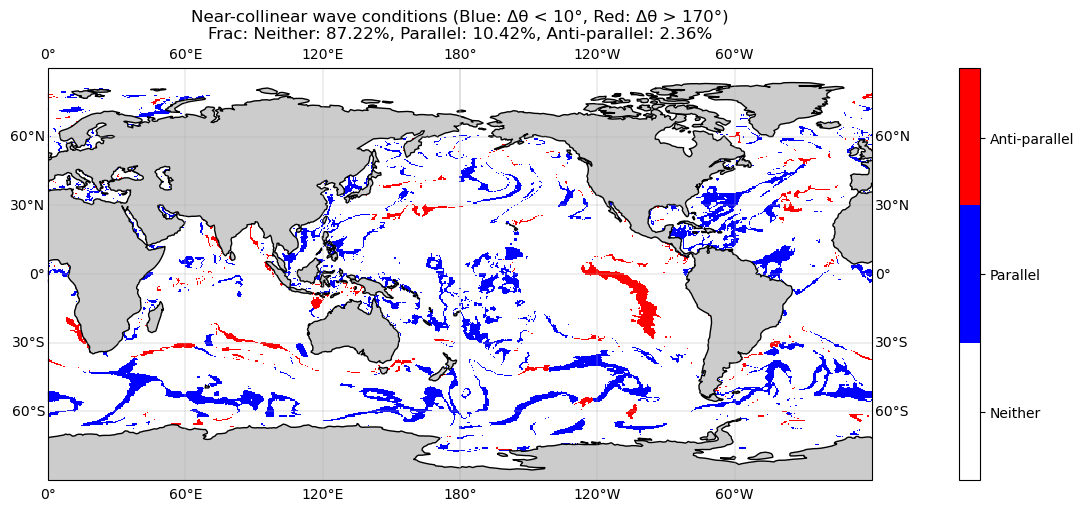

In [25]:
from matplotlib.colors import ListedColormap
t_test = 0
mask_type_t = mask_type.isel(time=t_test).compute()
valid_ocean = np.isfinite(mask_type_t)
n_total = valid_ocean.sum().item()

n_neither = (mask_type_t == 0).sum().item()
n_parallel = (mask_type_t == 1).sum().item()
n_antiparallel = (mask_type_t == 2).sum().item()

fraction_neither = n_neither / n_total
fraction_parallel = n_parallel / n_total
fraction_antiparallel = n_antiparallel / n_total

cmap = ListedColormap([
    "white",   # 0 = neither
    "blue",    # 1 = parallel
    "red"      # 2 = anti-parallel
])
fig, ax = plt.subplots(1, 1, figsize=(12, 5), 
                       subplot_kw={"projection": ccrs.PlateCarree(central_longitude=180)}, 
                       constrained_layout=True)

pcm = ax.pcolormesh(mask_type_t.longitude, mask_type_t.latitude, mask_type_t,
                    shading='auto', cmap=cmap, vmin=0, vmax=2, transform=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cfeature.LAND, facecolor="0.8", zorder=1)
ax.gridlines(draw_labels=True, linewidth=0.3)
ax.set_title(f"Near-collinear wave conditions (Blue: Δθ < 10°, Red: Δθ > 170°)\n" f"Frac: Neither: {fraction_neither:.2%}, Parallel: {fraction_parallel:.2%}, Anti-parallel: {fraction_antiparallel:.2%}")
# custom colorbar
cbar = plt.colorbar(pcm, ax=ax, ticks=[0.33, 1, 1.66])
cbar.ax.set_yticklabels(["Neither", "Parallel", "Anti-parallel"])

outpath = "/home/m/m301254/project_surfwaves/figs/era5_Stokes_profile/collinearity_map_10deg_2024-01-01T00Z.png"
plt.savefig(outpath, dpi=100)
plt.show()

## Stokes transports in 2 components

In [ ]:
# chunk
chunks = {"time": 96, "latitude": 88, "longitude": 176}

# paras for wind waves
shww = wave_globe["shww"].chunk(chunks)
p1ww = wave_globe["p1ww"].chunk(chunks)
mdww = wave_globe["mdww"].chunk(chunks)

# paras for total swells
shts = wave_globe["shts"].chunk(chunks)
p1ps = wave_globe["p1ps"].chunk(chunks)
mdts = wave_globe["mdts"].chunk(chunks)

In [8]:
# Wind wave (ww)
Vst_u_ww, Vst_v_ww = estimate_stokes_transport(shww, p1ww, mdww)
ds_Vst_ww = xr.Dataset({
    "Vst_u_ww":  Vst_u_ww,
    "Vst_v_ww":  Vst_v_ww
})
ds_Vst_ww.to_netcdf("/work/mh0033/m301254/proj_surfwave/processed_data/era5/hourly/era5_Stokes_transport_estimated_windwave_2024.nc")

/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 10.76 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [10]:
# Total Swells (ts)
Vst_u_ts, Vst_v_ts = estimate_stokes_transport(shts, p1ps, mdts)
ds_Vst_ts = xr.Dataset({
    "Vst_u_ts":  Vst_u_ts,
    "Vst_v_ts":  Vst_v_ts
})
ds_Vst_ts.to_netcdf("/work/mh0033/m301254/proj_surfwave/processed_data/era5/hourly/era5_Stokes_transport_estimated_totalswell_2024.nc")

/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 10.55 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


## Phillips Spectrum Profile (Breivik et al. 2016)

### Test 1: Raw Ust_ww and Ust_ts

In [ ]:
# ---------------------------------------------
# Test 1: use the raw Ust_ww and Ust_ts for decomposition, 
# without enforcing non-negativity 
# (mathematically exact but physically questionable)
# ---------------------------------------------

In [ ]:
# settings
chunks = {"time": 96, "latitude": 88, "longitude": 176}
time_sel = slice("2024-01-01", "2024-02-01")
THRESHOLD = np.pi / 12   # 10 degree
EPS = 1e-12

# surface Stokes
ust0 = (stokes_globe["ust"].sel(time=time_sel).chunk(chunks))
vst0 = (stokes_globe["vst"].sel(time=time_sel).chunk(chunks))
mdww = (wave_globe["mdww"].sel(time=time_sel).chunk(chunks))
mdts = (wave_globe["mdts"].sel(time=time_sel).chunk(chunks))

# ust0/vst0: eastward = U*sin(theta); northward = U*cos(theta)
# theta: clockwise from north -> surface Stokes direction
theta = np.arctan2(ust0, vst0) # GOING to direction, in radians, range [-pi, pi]
# era5 wave direction: direction waves are coming from, convert to GOING to direction
theta_ww = np.deg2rad((mdww + 180) % 360)
theta_ts = np.deg2rad((mdts + 180) % 360)
theta_ww_alt = ((np.deg2rad(mdww + 180) + np.pi) % (2*np.pi)) - np.pi
theta_ts_alt = ((np.deg2rad(mdts + 180) + np.pi) % (2*np.pi)) - np.pi

# angular difference between wind wave and total swell direction
dtheta_ww_ts = np.abs(theta_ww - theta_ts)
# wrap to [0, pi]
dtheta_ww_ts = xr.where(dtheta_ww_ts > np.pi, 2 * np.pi - dtheta_ww_ts, dtheta_ww_ts)

# mask
valid_ocean = np.isfinite(theta) # checked to be identical to np.isfinite(theta_ww) and np.isfinite(theta_ts)
mask_collinear = (valid_ocean & ((dtheta_ww_ts < THRESHOLD) | (dtheta_ww_ts > (np.pi - THRESHOLD))))
mask_non_collinear = valid_ocean & (~mask_collinear)

# mask fileds BEFORE decomposition
ust0_nc = ust0.where(mask_non_collinear)
vst0_nc = vst0.where(mask_non_collinear)
theta_nc = theta.where(mask_non_collinear)
# theta_ww_nc = theta_ww.where(mask_non_collinear)
# theta_ts_nc = theta_ts.where(mask_non_collinear)

# debug
theta_ww_nc = theta_ww_alt.where(mask_non_collinear)
theta_ts_nc = theta_ts_alt.where(mask_non_collinear)

# surface Stokes magnitude
Ust = xr.apply_ufunc(
    np.hypot, ust0_nc, vst0_nc,
    dask="parallelized",
    output_dtypes=[float]
)

# decomposition
# sin_ww_ts = np.sin(theta_ww_nc - theta_ts_nc)
# sin_theta_ts = np.sin(theta_nc - theta_ts_nc)
# sin_theta_ww = np.sin(theta_nc - theta_ww_nc)

# debug
def angle_diff(a, b):
    return np.arctan2(np.sin(a-b), np.cos(a-b))
sin_ww_ts = np.sin(angle_diff(theta_ww_nc, theta_ts_nc))
sin_theta_ts = np.sin(angle_diff(theta_nc, theta_ts_nc))
sin_theta_ww = np.sin(angle_diff(theta_nc, theta_ww_nc))

# safety against residual tiny denominator
sin_ww_ts_safe = xr.where(np.abs(sin_ww_ts) > EPS, sin_ww_ts, np.nan)

# raw magnitude (scalar)
Ust_ww_raw = (Ust * sin_theta_ts) / sin_ww_ts_safe
Ust_ts_raw = (Ust * sin_theta_ww) / (-sin_ww_ts_safe)

# keep nonnegative (physically acceptable)
# effectively doing: 
#   if ust_ww_raw is physically acceptable, keep it, reconstruct ts if needed; mask out the rest to NaN
#   if ts_raw is physically acceptable, keep it, reconstruct ww if needed; mask out the rest to NaN
Ust_ww = xr.where(Ust_ww_raw >= 0, Ust_ww_raw, np.nan)
Ust_ts = xr.where(Ust_ts_raw >= 0, Ust_ts_raw, np.nan)

# direction unir vector
e_ww_u = np.sin(theta_ww_nc)
e_ww_v = np.cos(theta_ww_nc)
e_ts_u = np.sin(theta_ts_nc)
e_ts_v = np.cos(theta_ts_nc)

# exact decomposition
Ust_ww = Ust_ww_raw.where(mask_non_collinear)
Ust_ts = Ust_ts_raw.where(mask_non_collinear)

ust0_ww = Ust_ww * np.sin(theta_ww_nc)
vst0_ww = Ust_ww * np.cos(theta_ww_nc)

ust0_ts = Ust_ts * np.sin(theta_ts_nc)
vst0_ts = Ust_ts * np.cos(theta_ts_nc)

# when collinear
ust0_direct = ust0.where(mask_collinear)
vst0_direct = vst0.where(mask_collinear)

In [13]:
# test finite ocean
finite_theta = np.isfinite(theta)
finite_ww = np.isfinite(theta_ww)
finite_ts = np.isfinite(theta_ts)

print("theta finite:", finite_theta.sum().compute().item())
print("theta_ww finite:", finite_ww.sum().compute().item())
print("theta_ts finite:", finite_ts.sum().compute().item())

theta finite: 110439520
theta_ww finite: 110439520
theta_ts finite: 110439520


In [7]:
print("theta vs ww mismatches:",
      (finite_theta != finite_ww).sum().compute().item())

print("theta vs ts mismatches:",
      (finite_theta != finite_ts).sum().compute().item())

print("ww vs ts mismatches:",
      (finite_ww != finite_ts).sum().compute().item())

/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 12.73 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


theta vs ww mismatches: 0


/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 12.73 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


theta vs ts mismatches: 0


/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 10.12 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


ww vs ts mismatches: 0


In [ ]:
# # reconstruct other components:
# # if ust_ww is valid, solve for magnitude Ust_ts
# Ust_ts_from_ww = xr.apply_ufunc(
#     np.hypot,
#     ust0_nc - Ust_ww * e_ww_u,
#     vst0_nc - Ust_ww * e_ww_v,
#     dask="parallelized",
#     output_dtypes=[float]
# )
# # if ust_ts is valid, solve for magnitude Ust_ww
# Ust_ww_from_ts = xr.apply_ufunc(
#     np.hypot,
#     ust0_nc - Ust_ts * e_ts_u,
#     vst0_nc - Ust_ts * e_ts_v,
#     dask="parallelized",
#     output_dtypes=[float]
# )

# Ust_ww = Ust_ww.fillna(Ust_ww_from_ts)
# Ust_ts = Ust_ts.fillna(Ust_ts_from_ww)

# # Make sure to keep only non-collinear cases
# Ust_ww = xr.where(mask_non_collinear, Ust_ww, np.nan)
# Ust_ts = xr.where(mask_non_collinear, Ust_ts, np.nan)

# # reconstruct from scalar to vector
# ust0_ww = Ust_ww * e_ww_u
# vst0_ww = Ust_ww * e_ww_v

# ust0_ts = Ust_ts * e_ts_u
# vst0_ts = Ust_ts * e_ts_v

# # Collinear direct branch
# ust0_direct = ust0.where(mask_collinear)
# vst0_direct = vst0.where(mask_collinear)

In [ ]:
# Validate decomposition BEFORE Phillips reconstruction
# reconstructed total surface Stokes velocity
ust0_reconstructed = (
    ust0_ww.fillna(0)
    + ust0_ts.fillna(0)
    + ust0_direct.fillna(0)
)
vst0_reconstructed = (
    vst0_ww.fillna(0)
    + vst0_ts.fillna(0)
    + vst0_direct.fillna(0)
)
# reconstruction error
du = ust0_reconstructed - ust0
dv = vst0_reconstructed - vst0

err = np.hypot(du, dv)
print("mean:", err.mean().compute().item())
print("99.9%:", err.quantile(0.999).compute().item())
print("max:", err.max().compute().item())

/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 12.77 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


mean: 8.760785650220019e-09


/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 12.77 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


99.9%: 1.1272366634797153e-07


/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 12.77 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


max: 1.0600256328924625e-06


In [46]:
print("max |du| =", np.abs(du).max().compute().item())
print("max |dv| =", np.abs(dv).max().compute().item())
print("mean |du| =", np.abs(du).mean().compute().item())
print("mean |dv| =", np.abs(dv).mean().compute().item())

/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 12.76 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


max |du| = 4.683259078319679e-07


/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 12.76 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


max |dv| = 1.0528260929731914e-06


/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 12.76 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


mean |du| = 5.567364430393437e-09


/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 12.76 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


mean |dv| = 5.5536083510613055e-09


In [47]:
du_nc = (
    ust0_ww.fillna(0)
    + ust0_ts.fillna(0)
    - ust0_nc.fillna(0)
)

dv_nc = (
    vst0_ww.fillna(0)
    + vst0_ts.fillna(0)
    - vst0_nc.fillna(0)
)

err_nc = np.hypot(du_nc, dv_nc)

print("NC mean:", err_nc.mean().compute().item())
print("NC max:", err_nc.max().compute().item())

/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 12.76 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


NC mean: 4.846928872912353e-09


/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 12.76 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


NC max: 1.0600256328924625e-06


In [48]:
print("collinear points:",
      mask_collinear.sum().compute().item())

print("non-collinear points:",
      mask_non_collinear.sum().compute().item())

print("overlap:",
      (mask_collinear & mask_non_collinear).sum().compute().item())

print("missing:",
      (valid_ocean & ~(mask_collinear | mask_non_collinear)).sum().compute().item())

/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 12.73 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


collinear points: 14420262


/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 12.73 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


non-collinear points: 96019258


/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 12.73 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


overlap: 0


/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 12.73 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


missing: 0


In [63]:
# fraction of negative Ust_ww_raw and Ust_ts_raw
neg_ww = (Ust_ww_raw < 0).sum().compute().item()
neg_ts = (Ust_ts_raw < 0).sum().compute().item()
total = mask_non_collinear.sum().compute().item()

print("negative ww:", neg_ww / total)
print("negative ts:", neg_ts / total)

/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 12.75 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 12.75 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of

negative ww: 0.038951161806685244
negative ts: 0.21452806040739647


In [36]:
u_check = Ust_ww_raw * np.sin(theta_ww) + Ust_ts_raw * np.sin(theta_ts)
v_check = Ust_ww_raw * np.cos(theta_ww) + Ust_ts_raw * np.cos(theta_ts)

du_formula = u_check - ust0_nc
dv_formula = v_check - vst0_nc

err_formula = np.hypot(du_formula, dv_formula)

print("formula mean:", err_formula.mean().compute().item())
print("formula 99.9%:", err_formula.quantile(0.999).compute().item())
print("formula max:", err_formula.max().compute().item())

/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 12.75 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


formula mean: 3.048127454020473e-08


/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 12.76 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


formula 99.9%: 2.4575624024691933e-07


/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 12.75 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


formula max: 1.0445769476064015e-06


In [35]:
# load Stokes transport
ds_Vst_direct = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/processed_data/era5/hourly/era5_Stokes_transport_estimated_direct_2024.nc")
ds_Vst_ww = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/processed_data/era5/hourly/era5_Stokes_transport_estimated_windwave_2024.nc")
ds_Vst_ts = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/processed_data/era5/hourly/era5_Stokes_transport_estimated_totalswell_2024.nc")

Vst_u_direct = (ds_Vst_direct["Vst_u_direct"].sel(time=time_sel).chunk(chunks))
Vst_v_direct = (ds_Vst_direct["Vst_v_direct"].sel(time=time_sel).chunk(chunks))
Vst_u_ww = (ds_Vst_ww["Vst_u_ww"].sel(time=time_sel).chunk(chunks))
Vst_v_ww = (ds_Vst_ww["Vst_v_ww"].sel(time=time_sel).chunk(chunks))
Vst_u_ts = (ds_Vst_ts["Vst_u_ts"].sel(time=time_sel).chunk(chunks))
Vst_v_ts = (ds_Vst_ts["Vst_v_ts"].sel(time=time_sel).chunk(chunks))

In [36]:
# magnitude of transport
Vst_mag_direct = xr.apply_ufunc(
    np.hypot,
    Vst_u_direct,
    Vst_v_direct,
    dask="parallelized",
    output_dtypes=[float]
)

Vst_mag_ww = xr.apply_ufunc(
    np.hypot,
    Vst_u_ww,
    Vst_v_ww,
    dask="parallelized",
    output_dtypes=[float]
)

Vst_mag_ts = xr.apply_ufunc(
    np.hypot,
    Vst_u_ts,
    Vst_v_ts,
    dask="parallelized",
    output_dtypes=[float]
)

In [37]:
# Non-collinear cases
ust0_final_ww = ust0_ww.where(mask_non_collinear)
vst0_final_ww = vst0_ww.where(mask_non_collinear)
Vst_final_ww  = Vst_mag_ww.where(mask_non_collinear)

ust0_final_ts = ust0_ts.where(mask_non_collinear)
vst0_final_ts = vst0_ts.where(mask_non_collinear)
Vst_final_ts  = Vst_mag_ts.where(mask_non_collinear)

# Collinear cases
ust0_direct = ust0.where(mask_collinear)
vst0_direct = vst0.where(mask_collinear)
Vst_direct  = Vst_mag_direct.where(mask_collinear)

In [40]:
# Phillips profile function
import scipy.special as sps
def Phillips_profile(ust_surface, vst_surface, Vst_mag, beta=1.0):
    # surface velocity magnitude
    ust_mag = xr.apply_ufunc(
        np.hypot,
        ust_surface,
        vst_surface,
        dask="parallelized",
        output_dtypes=[float]
    )
    # Stokes transport (considered as scalar)
    Vst_safe = xr.where(
        Vst_mag > EPS,
        Vst_mag,
        np.nan
    )
    # inverse depth scale
    k_bar = (ust_mag / (2 * Vst_safe)) * (1 - 2 * beta / 3)
    # z-cooridnate
    z = xr.DataArray(
        np.array([0, 1, 2, 3, 4, 5, 7, 9, 11, 13, 15, 20, 25, 30, 40, 50]),
        dims="depth",
        coords={
            "depth": np.array([0, 1, 2, 3, 4, 5, 7, 9, 11, 13, 15, 20, 25, 30, 40, 50])
        }
    )

    # Phillips profile shape function
    arg = 2 * k_bar * z
    sqrt_arg = np.sqrt(arg)
    erfc_term = sps.erfc(sqrt_arg)
    f_z = (np.exp(-arg) - beta * np.sqrt(np.pi * arg) * erfc_term)

    # apply the shape function to two components
    ust_z = ust_surface * f_z
    vst_z = vst_surface * f_z

    ds = xr.Dataset({"ust_z": ust_z, "vst_z": vst_z, "k_bar": k_bar})
    ds = ds.assign_coords(depth=z)

    return ds

In [41]:
# reconstruct the profile
# non-collinear cases
ds_profile_ww = Phillips_profile(ust0_final_ww, vst0_final_ww, Vst_final_ww)
ds_profile_ts = Phillips_profile(ust0_final_ts, vst0_final_ts, Vst_final_ts)

# collinear cases
ds_profile_direct = Phillips_profile(ust0_direct, vst0_direct, Vst_direct)

In [42]:
# final chunks for consistency
final_chunks = {"time": 48, "latitude": 88, "longitude": 176, "depth": -1}
ds_profile_ww = ds_profile_ww.chunk(final_chunks)
ds_profile_ts = ds_profile_ts.chunk(final_chunks)
ds_profile_direct = ds_profile_direct.chunk(final_chunks)

ds_profile_ww = ds_profile_ww.astype("float32")
ds_profile_ts = ds_profile_ts.astype("float32")
ds_profile_direct = ds_profile_direct.astype("float32")

# Encoding settings for compression
encoding = {
    "ust_z": {"zlib": True, "complevel": 4, "shuffle": True, "chunksizes": (48, 88, 176, 16)},
    "vst_z": {"zlib": True, "complevel": 4, "shuffle": True, "chunksizes": (48, 88, 176, 16)},
    "k_bar": {"zlib": True, "complevel": 4, "shuffle": True, "chunksizes": (48, 88, 176)}
}

# save
outdir = "/work/mh0033/m301254/proj_surfwave/processed_data/era5/hourly/"

ds_profile_ww.to_netcdf(f"{outdir}era5_Stokes_profile_phillips_windwave_2024_Jan.nc", encoding=encoding)
ds_profile_ts.to_netcdf(f"{outdir}era5_Stokes_profile_phillips_totalswell_2024_Jan.nc", encoding=encoding)
ds_profile_direct.to_netcdf(f"{outdir}era5_Stokes_profile_phillips_direct_collinear_2024_Jan.nc", encoding=encoding)

/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 12.99 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/dask/_task_spec.py:759: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/dask/_task_spec.py:759: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/dask/_task_spec.py:759: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/home/m/m301254/.conda/envs/e

### Test 2: enforce nonnegativity

In [ ]:
# ---------------------------------------------
# Test 2:
# - Compute Ust_ww_raw.
#   - If Ust_ww_raw > 0:
#       compute Ust_ts_from_ww from vector closure with direction enforced;
#       if Ust_ts_from_ww > 0, keep both;
#       otherwise, fall back to no decomposition (use ust0 and vst0 directly).
#   - If Ust_ww_raw <= 0:
#       fall back to no decomposition (use ust0 and vst0 directly),
#       because the unique signed solution is not physically admissible under the positivity constraint. 
# 
# This is a positivity-constrained admissibility test for the two-partition decomposition.
# It keeps only cases where both partition magnitudes are nonnegative and exact vector closure is preserved.
# ---------------------------------------------

In [ ]:
# settings
chunks = {"time": 96, "latitude": 88, "longitude": 176}
time_sel = slice("2024-01-01", "2024-02-01")
THRESHOLD = np.pi / 18   # 10 degree
EPS = 1e-12

# surface Stokes and wave direction
ust0 = stokes_globe["ust"].sel(time=time_sel).chunk(chunks)
vst0 = stokes_globe["vst"].sel(time=time_sel).chunk(chunks)
mdww = wave_globe["mdww"].sel(time=time_sel).chunk(chunks)
mdts = wave_globe["mdts"].sel(time=time_sel).chunk(chunks)

# GOING-TO direction
theta = np.arctan2(ust0, vst0)
theta_ww = np.deg2rad((mdww + 180) % 360)
theta_ts = np.deg2rad((mdts + 180) % 360)

# optional robust wrapping form
def angle_diff(a, b):
    return np.arctan2(np.sin(a - b), np.cos(a - b))

# mask: collinear and non-collinear
dtheta = np.abs(angle_diff(theta_ww, theta_ts))
valid_ocean = np.isfinite(theta)
mask_collinear = valid_ocean & ((dtheta < THRESHOLD) | (dtheta > np.pi - THRESHOLD))
mask_noncollinear = valid_ocean & (~mask_collinear)

# apply decomposition to non-collinear cases only
ust0_nc = ust0.where(mask_noncollinear)
vst0_nc = vst0.where(mask_noncollinear)
theta_nc = theta.where(mask_noncollinear)
theta_ww_nc = theta_ww.where(mask_noncollinear)
theta_ts_nc = theta_ts.where(mask_noncollinear)

# Stokes magnitude
Ust0 = xr.apply_ufunc(
    np.hypot, ust0_nc, vst0_nc,
    dask="parallelized",
    output_dtypes=[float]
)

# geometry terms
sin_ww_ts = np.sin(angle_diff(theta_ww_nc, theta_ts_nc))
sin_t_ts  = np.sin(angle_diff(theta_nc, theta_ts_nc))
sin_t_ww  = np.sin(angle_diff(theta_nc, theta_ww_nc))
sin_ww_ts_safe = xr.where(np.abs(sin_ww_ts) > EPS, sin_ww_ts, np.nan)

# analytical solution (signed)
Ust0_ww_raw = (Ust0 * sin_t_ts) / sin_ww_ts_safe
Ust0_ts_raw = (Ust0 * sin_t_ww) / (-sin_ww_ts_safe)

# physical constraint: non-negative
Ust0_ww_raw = xr.where(Ust0_ww_raw >= 0, Ust0_ww_raw, np.nan)
Ust0_ts_raw = xr.where(Ust0_ts_raw >= 0, Ust0_ts_raw, np.nan)

# vector reconstruction
e_ww_u = np.sin(theta_ww_nc)
e_ww_v = np.cos(theta_ww_nc)
e_ts_u = np.sin(theta_ts_nc)
e_ts_v = np.cos(theta_ts_nc)

# case A: use ww first
Uts_from_ww = (
    (ust0_nc - Ust0_ww_raw * e_ww_u) * e_ts_u +
    (vst0_nc - Ust0_ww_raw * e_ww_v) * e_ts_v
)
# case B: use ts first
Uww_from_ts = (
    (ust0_nc - Ust0_ts_raw * e_ts_u) * e_ww_u +
    (vst0_nc - Ust0_ts_raw * e_ts_v) * e_ww_v
)

# enforce positivity again
Uts_from_ww = xr.where(Uts_from_ww >= 0, Uts_from_ww, np.nan)
Uww_from_ts = xr.where(Uww_from_ts >= 0, Uww_from_ts, np.nan)

# final selection logic
Ust_ww = xr.full_like(Ust, np.nan)
Ust_ts = xr.full_like(Ust, np.nan)

mask_case1 = mask_noncollinear & Ust0_ww_raw.notnull()
mask_case1 = mask_case1 & Uts_from_ww.notnull()
mask_case2 = mask_noncollinear & (~mask_case1) & Ust0_ts_raw.notnull()
mask_case2 = mask_case2 & Uww_from_ts.notnull()

Ust_ww = xr.where(mask_case1, Ust0_ww_raw, Ust_ww)
Ust_ts = xr.where(mask_case1, Uts_from_ww, Ust_ts)
Ust_ww = xr.where(mask_case2, Uww_from_ts, Ust_ww)
Ust_ts = xr.where(mask_case2, Ust0_ts_raw, Ust_ts)

# collinear cases
Uww_direct = xr.zeros_like(Ust).where(mask_collinear)
Uts_direct = xr.zeros_like(Ust).where(mask_collinear)
ust_direct = ust0.where(mask_collinear)
vst_direct = vst0.where(mask_collinear)

In [ ]:
# Check reconstruction
ust_rec = (
    (Ust_ww * e_ww_u).fillna(0) +
    (Ust_ts * e_ts_u).fillna(0) +
    ust_direct.fillna(0)
)

vst_rec = (
    (Ust_ww * e_ww_v).fillna(0) +
    (Ust_ts * e_ts_v).fillna(0) +
    vst_direct.fillna(0)
)

du = ust_rec - ust0
dv = vst_rec - vst0

err = np.hypot(du, dv)

print("mean:", err.mean().compute().item())
print("99.9%:", err.quantile(0.999).compute().item())
print("max:", err.max().compute().item())

print("max |du|:", np.abs(du).max().compute().item())
print("max |dv|:", np.abs(dv).max().compute().item())

### Test 3: Non-collinear + Positive convex cone
- For every **non-collinear** grid point, the 2D system has one unique signed solution for (Ust_ww and Ust_ts)
    - If that unique solution gives a negative coefficient, then the point is outside the positive cone spanned by the WW and TS directions, and there is no physically admissible positive decomposition. In that case, falling back to the direct mean-wave reconstruction is the correct choice.
- So the clean scientific rule is:
    - collinear → no decomposition, use direct
    - non-collinear and inside positive cone → decompose
    - non-collinear but outside positive cone → no decomposition, use direct
- Better to check the mask for each case:

In [4]:
# Settings
chunks = {"time": 48, "latitude": 88, "longitude": 176}
time_sel = slice("2024-01-01", "2024-02-01")
THRESHOLD = np.pi / 36   # 10 degrees, can try 5 degrees later
EPS = 1e-12
TOL = 1e-10  # small tolerance for positivity

# load stokes drift and wave direction
ust0 = stokes_globe["ust"].sel(time=time_sel).chunk(chunks)
vst0 = stokes_globe["vst"].sel(time=time_sel).chunk(chunks)
mdww = wave_globe["mdww"].sel(time=time_sel).chunk(chunks)
mdts = wave_globe["mdts"].sel(time=time_sel).chunk(chunks)

# convert to GOING-To direction in radians
theta = np.arctan2(ust0, vst0)  # GOING To; Clockwise from north
theta_ww = np.deg2rad((mdww + 180) % 360)
theta_ts = np.deg2rad((mdts + 180) % 360)

def angle_diff(a, b):
    return np.arctan2(np.sin(a - b), np.cos(a - b))

# Preliminary mask based on directional difference
dtheta = np.abs(angle_diff(theta_ww, theta_ts))
valid_ocean = np.isfinite(theta) # checked; identical to np.isfinite(theta_ww) and np.isfinite(theta_ts)
mask_collinear = valid_ocean & ((dtheta < THRESHOLD) | (dtheta > np.pi - THRESHOLD))
mask_noncollinear = valid_ocean & (~mask_collinear)

# Non-collinear cases
ust0_nc = ust0.where(mask_noncollinear)
vst0_nc = vst0.where(mask_noncollinear)
theta_nc = theta.where(mask_noncollinear)
theta_ww_nc = theta_ww.where(mask_noncollinear)
theta_ts_nc = theta_ts.where(mask_noncollinear)
# Stokes magnitude
Ust0 = xr.apply_ufunc(
    np.hypot, ust0_nc, vst0_nc,
    dask="parallelized",
    output_dtypes=[float]
)

# Excat analytical solution of magnitude (signed, unique in non-collinear cases)
sin_ww_ts = np.sin(angle_diff(theta_ww_nc, theta_ts_nc))
sin_t_ts  = np.sin(angle_diff(theta_nc, theta_ts_nc))
sin_t_ww  = np.sin(angle_diff(theta_nc, theta_ww_nc))
sin_ww_ts_safe = xr.where(np.abs(sin_ww_ts) > EPS, sin_ww_ts, np.nan)

Ust0_ww_raw = (Ust0 * sin_t_ts) / sin_ww_ts_safe
Ust0_ts_raw = (Ust0 * sin_t_ww) / (-sin_ww_ts_safe)

# Positivity / convex-cone admissibility test
# Accept the decomposition only if both components are non-negative 
# -> necessary condition for physical admissibility under the two-partition framework.
mask_noncolli_decomp_okay = mask_noncollinear & (Ust0_ww_raw >= -TOL) & (Ust0_ts_raw >= -TOL)
mask_noncolli_decomp_fail = mask_noncollinear & (~mask_noncolli_decomp_okay) # -> gives the non-collinear but non-admissible cases

Ust0_ww = xr.where(mask_noncolli_decomp_okay, Ust0_ww_raw, np.nan)
Ust0_ts = xr.where(mask_noncolli_decomp_okay, Ust0_ts_raw, np.nan)

# Reconstruct the vector components from the magnitudes and directions
e_ww_u = np.sin(theta_ww_nc)
e_ww_v = np.cos(theta_ww_nc)
e_ts_u = np.sin(theta_ts_nc)
e_ts_v = np.cos(theta_ts_nc)

ust0_ww = (Ust0_ww * e_ww_u).where(mask_noncolli_decomp_okay)
vst0_ww = (Ust0_ww * e_ww_v).where(mask_noncolli_decomp_okay)
ust0_ts = (Ust0_ts * e_ts_u).where(mask_noncolli_decomp_okay)
vst0_ts = (Ust0_ts * e_ts_v).where(mask_noncolli_decomp_okay)

# Collinear + decomp_fail cases: fallback to direct representation without decomposition
mask_direct = mask_collinear | mask_noncolli_decomp_fail
ust0_direct = ust0.where(mask_direct)
vst0_direct = vst0.where(mask_direct)

#### Test on surface Stokes velocity decomposition

In [12]:
# diagnostic: check reconstruction error
ust_rec = (
    ust0_ww.fillna(0)
    + ust0_ts.fillna(0)
    + ust0_direct.fillna(0)
)

vst_rec = (
    vst0_ww.fillna(0)
    + vst0_ts.fillna(0)
    + vst0_direct.fillna(0)
)

du = ust_rec - ust0
dv = vst_rec - vst0
err = np.hypot(du, dv)

print("mean:", err.mean().compute().item())
print("99.9%:", err.quantile(0.999).compute().item())
print("max:", err.max().compute().item())

print("noncollinear + accepted decomposition fraction:",
      mask_noncolli_decomp_okay.sum().compute().item() / valid_ocean.sum().compute().item())
print("noncollinear + failed decomposition fraction:",
      mask_noncolli_decomp_fail.sum().compute().item() / valid_ocean.sum().compute().item())
print("Total rejected fraction:",
      mask_direct.sum().compute().item() / valid_ocean.sum().compute().item())

/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 12.77 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


mean: 1.1871830924423498e-08


/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 12.77 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


99.9%: 3.893788944831587e-07


/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 12.77 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


...

noncollinear + accepted decomposition fraction: 0.6735268370824974


/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 12.75 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


noncollinear + failed decomposition fraction: 0.2470174032814255


/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 12.75 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Total rejected fraction: 0.3264731629175026


/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 12.76 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


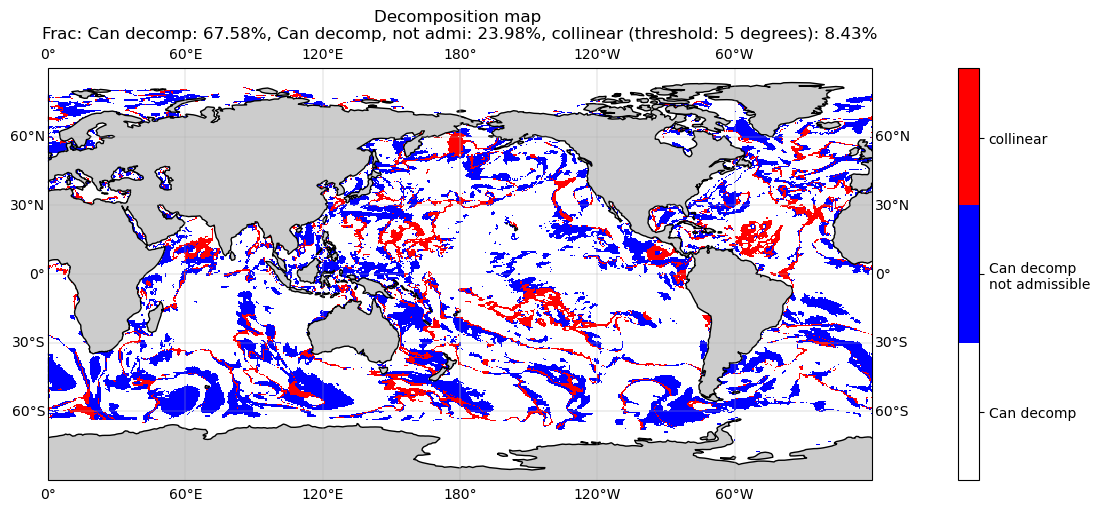

In [17]:
# plot masks for a sample time step
# 0 = can decompose and physically admissible
# 1 = can decompose but not physically admissible (fails positivity test)
# 2 = collinear
mask_type = xr.full_like(dtheta, np.nan)
mask_type = xr.where(mask_noncolli_decomp_okay, 0, mask_type)
mask_type = xr.where(mask_noncolli_decomp_fail, 1, mask_type)
mask_type = xr.where(mask_collinear, 2, mask_type)

from matplotlib.colors import ListedColormap
t_test = 100
mask_type_t = mask_type.isel(time=t_test).compute()
valid_ocean = np.isfinite(mask_type_t)
n_total = valid_ocean.sum().item()

n_neither = (mask_type_t == 0).sum().item()
n_parallel = (mask_type_t == 1).sum().item()
n_antiparallel = (mask_type_t == 2).sum().item()

fraction_neither = n_neither / n_total
fraction_parallel = n_parallel / n_total
fraction_antiparallel = n_antiparallel / n_total

cmap = ListedColormap([
    "white",   # 0 = can decompose
    "blue",    # 1 = can decompose but not admissible
    "red"      # 2 = parallel/anti-parallel (collinear)
])
fig, ax = plt.subplots(1, 1, figsize=(12, 5), 
                       subplot_kw={"projection": ccrs.PlateCarree(central_longitude=180)}, 
                       constrained_layout=True)

pcm = ax.pcolormesh(mask_type_t.longitude, mask_type_t.latitude, mask_type_t,
                    shading='auto', cmap=cmap, vmin=0, vmax=2, transform=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cfeature.LAND, facecolor="0.8", zorder=1)
ax.gridlines(draw_labels=True, linewidth=0.3)
ax.set_title(f"Decomposition map \n" f"Frac: Can decomp: {fraction_neither:.2%}, Can decomp, not admi: {fraction_parallel:.2%}, collinear (threshold: 5 degrees): {fraction_antiparallel:.2%}")
# custom colorbar
cbar = plt.colorbar(pcm, ax=ax, ticks=[0.33, 1, 1.66])
cbar.ax.set_yticklabels(["Can decomp", "Can decomp\nnot admissible", "collinear"])

outpath = "/home/m/m301254/project_surfwaves/figs/era5_Stokes_profile/collinearity_map_10deg_2024-07-01T00Z.png"
# plt.savefig(outpath, dpi=100)
plt.show()

#### Reconstruct profile (Phillips)

In [5]:
# load Stokes transport
ds_Vst_direct = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/processed_data/era5/hourly/era5_Stokes_transport_estimated_direct_2024.nc")
ds_Vst_ww = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/processed_data/era5/hourly/era5_Stokes_transport_estimated_windwave_2024.nc")
ds_Vst_ts = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/processed_data/era5/hourly/era5_Stokes_transport_estimated_totalswell_2024.nc")

Vst_u_direct = (ds_Vst_direct["Vst_u_direct"].sel(time=time_sel).chunk(chunks))
Vst_v_direct = (ds_Vst_direct["Vst_v_direct"].sel(time=time_sel).chunk(chunks))
Vst_u_ww = (ds_Vst_ww["Vst_u_ww"].sel(time=time_sel).chunk(chunks))
Vst_v_ww = (ds_Vst_ww["Vst_v_ww"].sel(time=time_sel).chunk(chunks))
Vst_u_ts = (ds_Vst_ts["Vst_u_ts"].sel(time=time_sel).chunk(chunks))
Vst_v_ts = (ds_Vst_ts["Vst_v_ts"].sel(time=time_sel).chunk(chunks))

# magnitude of transport
Vst_mag_direct = xr.apply_ufunc(
    np.hypot, Vst_u_direct, Vst_v_direct,
    dask="parallelized",
    output_dtypes=[float])
Vst_mag_ww = xr.apply_ufunc(
    np.hypot, Vst_u_ww, Vst_v_ww,
    dask="parallelized",
    output_dtypes=[float])
Vst_mag_ts = xr.apply_ufunc(
    np.hypot, Vst_u_ts, Vst_v_ts,
    dask="parallelized",
    output_dtypes=[float])

# Non-collinear & accepted decomposition cases
Vst_ww  = Vst_mag_ww.where(mask_noncolli_decomp_okay)
Vst_ts  = Vst_mag_ts.where(mask_noncolli_decomp_okay)
# Collinear & decomposition not admissible cases
Vst_direct  = Vst_mag_direct.where(mask_direct)

# Phillips profile function
import scipy.special as sps
def Phillips_profile(ust_surface, vst_surface, Vst_mag, beta=1.0):
    # surface velocity magnitude
    ust_mag = xr.apply_ufunc(
        np.hypot, ust_surface, vst_surface,
        dask="parallelized",
        output_dtypes=[float])
    # Stokes transport (considered as scalar)
    Vst_safe = xr.where(Vst_mag > EPS, Vst_mag, np.nan)
    # inverse depth scale
    k_bar = (ust_mag / (2 * Vst_safe)) * (1 - 2 * beta / 3)
    # z-cooridnate
    z = xr.DataArray(np.array([0, 1, 2, 3, 4, 5, 7, 9, 11, 13, 15, 20, 25, 30, 40, 50]),
                     dims="depth",
                     coords={
                         "depth": np.array([0, 1, 2, 3, 4, 5, 7, 9, 11, 13, 15, 20, 25, 30, 40, 50])
                         })
    # Phillips profile shape function
    arg = 2 * k_bar * z
    sqrt_arg = np.sqrt(arg)
    erfc_term = sps.erfc(sqrt_arg)
    f_z = (np.exp(-arg) - beta * np.sqrt(np.pi * arg) * erfc_term)
    # apply the shape function to two components
    ust_z = ust_surface * f_z
    vst_z = vst_surface * f_z
    ds = xr.Dataset({"ust_z": ust_z, "vst_z": vst_z, "k_bar": k_bar})
    ds = ds.assign_coords(depth=z)

    return ds

# reconstruct the profile
# non-collinear & accepted decomposition cases
ds_profile_ww = Phillips_profile(ust0_ww, vst0_ww, Vst_ww)
ds_profile_ts = Phillips_profile(ust0_ts, vst0_ts, Vst_ts)
# collinear & decomposition not admissible cases
ds_profile_direct = Phillips_profile(ust0_direct, vst0_direct, Vst_direct)

# final chunks for consistency
final_chunks = {"time": 48, "latitude": 88, "longitude": 176, "depth": -1}
ds_profile_ww = ds_profile_ww.chunk(final_chunks)
ds_profile_ts = ds_profile_ts.chunk(final_chunks)
ds_profile_direct = ds_profile_direct.chunk(final_chunks)
ds_profile_ww = ds_profile_ww.astype("float32")
ds_profile_ts = ds_profile_ts.astype("float32")
ds_profile_direct = ds_profile_direct.astype("float32")

# Encoding settings for compression
encoding = {
    "ust_z": {"zlib": True, "complevel": 4, "shuffle": True, "chunksizes": (48, 88, 176, 16)},
    "vst_z": {"zlib": True, "complevel": 4, "shuffle": True, "chunksizes": (48, 88, 176, 16)},
    "k_bar": {"zlib": True, "complevel": 4, "shuffle": True, "chunksizes": (48, 88, 176)}
}

# save
outdir = "/work/mh0033/m301254/proj_surfwave/processed_data/era5/hourly/"
ds_profile_ww.to_netcdf(f"{outdir}era5_Stokes_profile_phillips_decomp_windwave_2024_Jan_thres05.nc", encoding=encoding)
ds_profile_ts.to_netcdf(f"{outdir}era5_Stokes_profile_phillips_decomp_totalswell_2024_Jan_thres05.nc", encoding=encoding)
ds_profile_direct.to_netcdf(f"{outdir}era5_Stokes_profile_phillips_no-decomp_direct_2024_Jan_thres05.nc", encoding=encoding)

/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 12.99 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 12.99 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/m/m301254/.conda/envs/env02_waves/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of

### Evaluate result

In [ ]:
outdir = "/work/mh0033/m301254/proj_surfwave/processed_data/era5/hourly/"
final_chunks = {"time": 96, "latitude": 88, "longitude": 176, "depth": -1}
profile_ww = xr.open_dataset(f"{outdir}era5_Stokes_profile_phillips_decomp_windwave_2024_Jan_thres05.nc", chunks=final_chunks)
profile_ts = xr.open_dataset(f"{outdir}era5_Stokes_profile_phillips_decomp_totalswell_2024_Jan_thres05.nc", chunks=final_chunks)
profile_di = xr.open_dataset(f"{outdir}era5_Stokes_profile_phillips_no-decomp_direct_2024_Jan_thres05.nc", chunks=final_chunks)

In [4]:
# southern ocean region, check 3 cases
profile_ww_so = profile_ww.sel(latitude=slice(-50, -55), longitude=slice(260, 265))
profile_ts_so = profile_ts.sel(latitude=slice(-50, -55), longitude=slice(260, 265))
profile_di_so = profile_di.sel(latitude=slice(-50, -55), longitude=slice(260, 265))

# Tropical Pacific region
profile_ww_tp = profile_ww.sel(latitude=slice(0, -5), longitude=slice(260, 265))
profile_ts_tp = profile_ts.sel(latitude=slice(0, -5), longitude=slice(260, 265))
profile_di_tp = profile_di.sel(latitude=slice(0, -5), longitude=slice(260, 265))

# time-averaged regional-mean profile
# profile_ww_so_mean = profile_ww_so.mean(dim={"time", "latitude", "longitude"})
# profile_ts_so_mean = profile_ts_so.mean(dim={"time", "latitude", "longitude"})

# profile_ww_tp_mean = profile_ww_tp.mean(dim={"time", "latitude", "longitude"})
# profile_ts_tp_mean = profile_ts_tp.mean(dim={"time", "latitude", "longitude"})

# regional-mean profile
profile_ww_so_reg = profile_ww_so.mean(dim={"latitude", "longitude"})
profile_ts_so_reg = profile_ts_so.mean(dim={"latitude", "longitude"})
profile_di_so_reg = profile_di_so.mean(dim={"latitude", "longitude"})

profile_ww_tp_reg = profile_ww_tp.mean(dim={"latitude", "longitude"})
profile_ts_tp_reg = profile_ts_tp.mean(dim={"latitude", "longitude"})
profile_di_tp_reg = profile_di_tp.mean(dim={"latitude", "longitude"})

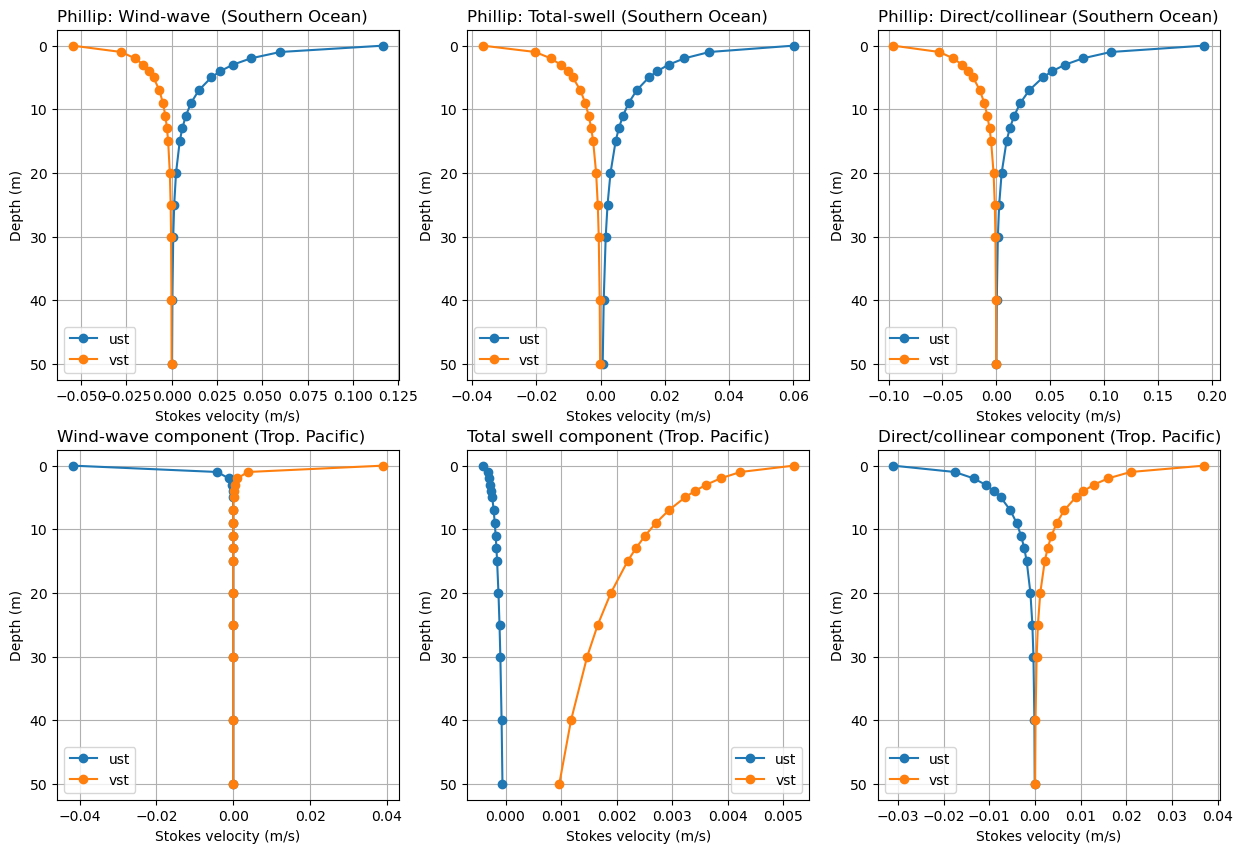

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
def plot_profile(ax, profile, title, time=500):
    ax.plot(profile["ust_z"].isel(time=time), profile["depth"], label="ust", marker="o")
    ax.plot(profile["vst_z"].isel(time=time), profile["depth"], label="vst", marker="o")
    ax.invert_yaxis()
    ax.set_xlabel("Stokes velocity (m/s)")
    ax.set_ylabel("Depth (m)")
    ax.set_title(title, loc="left")
    ax.legend()
    ax.grid()

axes = axes.flatten()
plot_profile(axes[0], profile_ww_so_reg, "Phillip: Wind-wave  (Southern Ocean)", time=500)
plot_profile(axes[1], profile_ts_so_reg, "Phillip: Total-swell (Southern Ocean)", time=500)
plot_profile(axes[2], profile_di_so_reg, "Phillip: Direct/collinear (Southern Ocean)", time=500) 
plot_profile(axes[3], profile_ww_tp_reg, "Wind-wave component (Trop. Pacific)", time=500)
plot_profile(axes[4], profile_ts_tp_reg, "Total swell component (Trop. Pacific)", time=500)
plot_profile(axes[5], profile_di_tp_reg, "Direct/collinear component (Trop. Pacific)", time=500) 

In [5]:
# actual final profile: ust(z,t) = ust_ww(z,t) + ust_ts(z,t) + ust_direct(z,t), and similarly for vst
profile_final = xr.Dataset({
    "ust_z": (
        profile_ww["ust_z"].fillna(0)
        + profile_ts["ust_z"].fillna(0)
        + profile_di["ust_z"].fillna(0)
    ),
    "vst_z": (
        profile_ww["vst_z"].fillna(0)
        + profile_ts["vst_z"].fillna(0)
        + profile_di["vst_z"].fillna(0)
    )
})

# assign depth coordinate from the original profile
profile_final = profile_final.assign_coords(depth=profile_ww["depth"])
# assign region, and regional mean
profile_final_so = profile_final.sel(latitude=slice(-50, -55),longitude=slice(260, 265))
profile_final_tp = profile_final.sel(latitude=slice(0, -5), longitude=slice(260, 265))
profile_final_so_reg = profile_final_so.mean(dim={"latitude", "longitude"}, skipna=True)
profile_final_tp_reg = profile_final_tp.mean(dim={"latitude", "longitude"}, skipna=True)

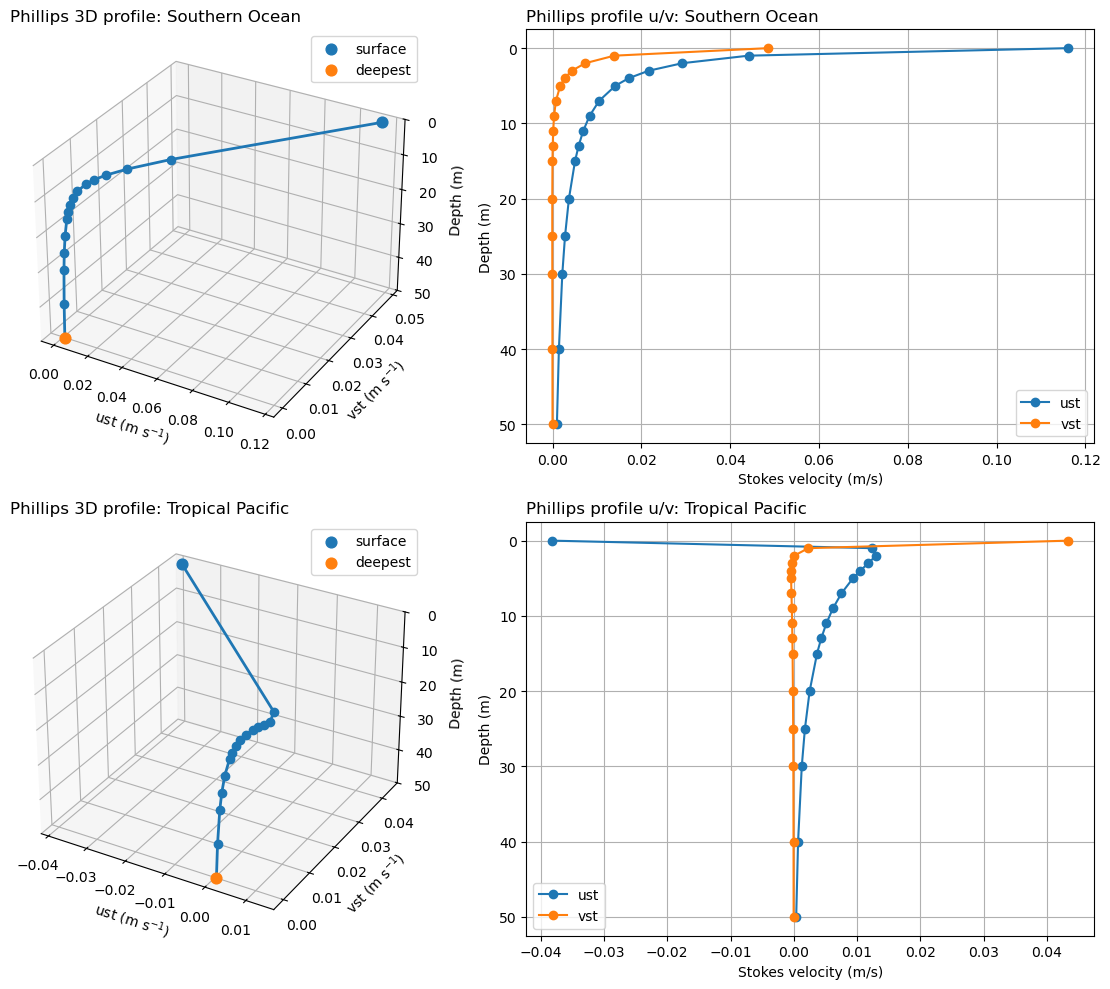

In [9]:
from mpl_toolkits.mplot3d import Axes3D
def plot_3d_profile(ax, profile, title, time=500):
    u = profile["ust_z"].isel(time=time)
    v = profile["vst_z"].isel(time=time)
    depth = profile["depth"]

    # load small 1D arrays for plotting
    u = u.compute() if hasattr(u.data, "compute") else u
    v = v.compute() if hasattr(v.data, "compute") else v

    ax.plot(u, v, depth, marker="o", linewidth=2)

    # mark surface and deepest point
    ax.scatter(u.isel(depth=0), v.isel(depth=0), depth.isel(depth=0),
               s=60, label="surface")
    ax.scatter(u.isel(depth=-1), v.isel(depth=-1), depth.isel(depth=-1),
               s=60, label="deepest")

    ax.set_xlabel("ust (m s$^{-1}$)")
    ax.set_ylabel("vst (m s$^{-1}$)")
    ax.set_zlabel("Depth (m)")
    ax.set_title(title, loc="left")

    # make depth increase downward
    ax.set_zlim(depth.max(), depth.min())

    ax.grid(True)
    ax.legend()

fig = plt.figure(figsize=(12, 10))
time_t = 100
ax1 = fig.add_subplot(2, 2, 1, projection="3d")
plot_3d_profile(ax1, profile_final_so_reg, "Phillips 3D profile: Southern Ocean", time=time_t)
ax2 = fig.add_subplot(2, 2, 2)
plot_profile(ax2, profile_final_so_reg, "Phillips profile u/v: Southern Ocean", time=time_t)
ax3 = fig.add_subplot(2, 2, 3, projection="3d")
plot_3d_profile(ax3, profile_final_tp_reg, "Phillips 3D profile: Tropical Pacific", time=time_t)
ax4 = fig.add_subplot(2, 2, 4)
plot_profile(ax4, profile_final_tp_reg, "Phillips profile u/v: Tropical Pacific", time=time_t)

plt.tight_layout()
plt.show()

# Compare: global no-separation (Total-sea) to partially decomposed (PARTITIONED)

In [9]:
# read 
outdir = "/work/mh0033/m301254/proj_surfwave/processed_data/era5/hourly/"
final_chunks = {"time": 96, "latitude": 88, "longitude": 176, "depth": -1}
# total sea
p_totalsea = xr.open_dataset(f"{outdir}era5_Stokes_profile_phillips_2024_Jan_Redo.nc", chunks=final_chunks)

# partitioned
p_parti_ww = xr.open_dataset(f"{outdir}era5_Stokes_profile_phillips_decomp_windwave_2024_Jan_thres05.nc", chunks=final_chunks)
p_parti_ts = xr.open_dataset(f"{outdir}era5_Stokes_profile_phillips_decomp_totalswell_2024_Jan_thres05.nc", chunks=final_chunks)
p_parti_di = xr.open_dataset(f"{outdir}era5_Stokes_profile_phillips_no-decomp_direct_2024_Jan_thres05.nc", chunks=final_chunks)

# final profile: ust(z,t) = ust_ww(z,t) + ust_ts(z,t) + ust_direct(z,t)
p_partitioned = xr.Dataset({
    "ust_z": (
        p_parti_ww["ust_z"].fillna(0)
        + p_parti_ts["ust_z"].fillna(0)
        + p_parti_di["ust_z"].fillna(0)
    ),
    "vst_z": (
        p_parti_ww["vst_z"].fillna(0)
        + p_parti_ts["vst_z"].fillna(0)
        + p_parti_di["vst_z"].fillna(0)
    )
})
p_partitioned = p_partitioned.assign_coords(depth=p_parti_ww["depth"])
p_totalsea, p_partitioned = xr.align(p_totalsea, p_partitioned, join="exact")

In [10]:
uT = p_totalsea["ust_z"]
vT = p_totalsea["vst_z"]
uP = p_partitioned["ust_z"]
vP = p_partitioned["vst_z"]

spdT = np.hypot(uT, vT)
spdP = np.hypot(uP, vP)

du = uP - uT
dv = vP - vT

dvec = np.hypot(du, dv)
dspd = spdP - spdT

rel_dvec = dvec / xr.where(spdT > 1e-8, spdT, np.nan)

dot = uT * uP + vT * vP
cosang = dot / xr.where((spdT * spdP) > 1e-12, spdT * spdP, np.nan)
angle_diff = np.rad2deg(np.arccos(cosang.clip(-1, 1)))

## surface

In [11]:
# surface truly identical?
surf = dict(depth=0)
print("surface max vector difference:")
print(float(dvec.sel(surf).max().compute()))
print("surface p99 vector difference:")
print(float(dvec.sel(surf).quantile(0.99).compute()))
print("surface max angle difference:")
print(float(angle_diff.sel(surf).max().compute()))

surface max vector difference:
0.5390416979789734
surface p99 vector difference:
0.011302041867747914
surface max angle difference:
174.8166046142578


## subsurface

In [13]:
# subsurface difference by depth
w = np.cos(np.deg2rad(p_totalsea["latitude"]))
w = w / w.mean()

def weighted_mean(da):
    return da.weighted(w).mean(("time", "latitude", "longitude"))

depth_stats = xr.Dataset({
    "mean_abs_vector_diff": weighted_mean(dvec),
    "rms_vector_diff": np.sqrt(weighted_mean(dvec**2)),
    "mean_relative_vector_diff": weighted_mean(rel_dvec),
    "relative_vector_diff_quantiles": rel_dvec.quantile(
        [0.50, 0.90, 0.99],
        dim=("time", "latitude", "longitude"),
    ),
    "mean_angle_diff_deg": weighted_mean(angle_diff),
    "angle_diff_quantiles": angle_diff.quantile(
        [0.50, 0.90, 0.99],
        dim=("time", "latitude", "longitude"),
    ),
})

print(depth_stats.compute())

<xarray.Dataset> Size: 1kB
Dimensions:                         (depth: 16, quantile: 3)
Coordinates:
  * depth                           (depth) int64 128B 0 1 2 3 4 ... 25 30 40 50
  * quantile                        (quantile) float64 24B 0.5 0.9 0.99
    number                          int64 8B 0
    step                            timedelta64[ns] 8B 00:00:00
    meanSea                         float64 8B 0.0
Data variables:
    mean_abs_vector_diff            (depth) float64 128B 0.0004161 ... 0.0005221
    rms_vector_diff                 (depth) float64 128B 0.004576 ... 0.0008557
    mean_relative_vector_diff       (depth) float64 128B 0.02629 ... 133.0
    relative_vector_diff_quantiles  (quantile, depth) float64 384B 7.424e-08 ...
    mean_angle_diff_deg             (depth) float64 128B 0.8235 13.3 ... 34.66
    angle_diff_quantiles            (quantile, depth) float64 384B 0.0 ... 152.4


## depth-integrated transport 
- TOTAL-SEA use mean wave, PARTITIONED use mean wave for ww/ts

In [15]:
UT = xr.Dataset({
    "Ust_transport": uT.integrate("depth"),
    "Vst_transport": vT.integrate("depth"),
})

UP = xr.Dataset({
    "Ust_transport": uP.integrate("depth"),
    "Vst_transport": vP.integrate("depth"),
})

Tmag = np.hypot(UT["Ust_transport"], UT["Vst_transport"])
Pmag = np.hypot(UP["Ust_transport"], UP["Vst_transport"])

Dmag = np.hypot(
    UP["Ust_transport"] - UT["Ust_transport"],
    UP["Vst_transport"] - UT["Vst_transport"],
)

rel_transport_diff = Dmag / xr.where(Tmag > 1e-8, Tmag, np.nan)

print(rel_transport_diff.quantile([0.5, 0.9, 0.95, 0.99]).compute())

<xarray.DataArray 'Ust_transport' (quantile: 4)> Size: 32B
array([0.19133136, 0.87510071, 1.11203709, 1.52324452])
Coordinates:
  * quantile  (quantile) float64 32B 0.5 0.9 0.95 0.99


## gradient

In [16]:
duT_dz = uT.differentiate("depth")
dvT_dz = vT.differentiate("depth")
duP_dz = uP.differentiate("depth")
dvP_dz = vP.differentiate("depth")

shearT = np.hypot(duT_dz, dvT_dz)
shearP = np.hypot(duP_dz, dvP_dz)

dshear = np.hypot(duP_dz - duT_dz, dvP_dz - dvT_dz)
rel_shear_diff = dshear / xr.where(shearT > 1e-10, shearT, np.nan)

print("relative shear difference:")
print(rel_shear_diff.quantile([0.5, 0.9, 0.95, 0.99], dim=("time", "latitude", "longitude")).compute())

relative shear difference:
<xarray.DataArray 'ust_z' (quantile: 4, depth: 16)> Size: 512B
array([[1.83844887e-01, 1.38164103e-01, 5.40542677e-02, 1.30841635e-01,
        2.00786375e-01, 2.49999970e-01, 3.16028550e-01, 3.61286312e-01,
        3.86657789e-01, 4.01154637e-01, 4.08560455e-01, 4.24660742e-01,
        4.74454820e-01, 5.47151983e-01, 7.57820547e-01, 9.76102769e-01],
       [1.07497227e+00, 7.31969661e-01, 6.54834515e-01, 8.25859493e-01,
        8.95668864e-01, 9.28701460e-01, 9.62720037e-01, 9.87047493e-01,
        1.00313616e+00, 1.03499626e+00, 1.07850196e+00, 1.26241636e+00,
        1.70786331e+00, 2.56246734e+00, 6.56477757e+00, 1.58403925e+01],
       [1.62782800e+00, 1.09897960e+00, 8.80110323e-01, 9.73401070e-01,
        1.00379801e+00, 1.03247274e+00, 1.08113802e+00, 1.13793528e+00,
        1.20172870e+00, 1.28054976e+00, 1.36838031e+00, 1.67586541e+00,
        2.67404246e+00, 4.93326392e+00, 1.44082491e+01, 4.02765129e+01],
       [4.08719874e+00, 2.81836019e+00, 2.0

In [ ]:
# Mean and percentile relative vector difference by depth
fig, ax = plt.subplots(figsize=(4, 5))
depth_stats["mean_relative_vector_diff"].plot(
    y="depth",
    yincrease=False,
    ax=ax,
    label="mean",
)
depth_stats["relative_vector_diff_quantiles"].sel(quantile=0.5).plot(
    y="depth",
    yincrease=False,
    ax=ax,
    label="p50",
)
depth_stats["relative_vector_diff_quantiles"].sel(quantile=0.9).plot(
    y="depth",
    yincrease=False,
    ax=ax,
    label="p90",
)
depth_stats["relative_vector_diff_quantiles"].sel(quantile=0.99).plot(
    y="depth",
    yincrease=False,
    ax=ax,
    label="p99",
)
ax.set_xlabel("relative vector difference")
ax.set_ylabel("depth [m]")
ax.legend()
ax.grid(True)
plt.show()

In [ ]:
rel_transport_diff.mean("time").plot(
    vmin=0,
    vmax=1,
    cmap="magma",
)

rel_dvec.sel(depth=10).mean("time").plot(
    vmin=0,
    vmax=1,
    cmap="magma",
)

rel_dvec.sel(depth=30).mean("time").plot(
    vmin=0,
    vmax=1,
    cmap="magma",
)